<div style="text-align:center;">
  <h1 size=10>
    <b>BIG DATA ANALYTICS PROJECT</b><br>
    <b>Money Laundering Detection - IBM Transactions</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 10**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:** https://github.com/mariamiguel720/Big-Data-Analytics-Project-25-26

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Data Exploration](#4)
    - [4.1. Missing Values](#4_1)
    - [4.2. Duplicates](#4_2)
    - [4.3. Is Laundering Class Imbalance](#4_3)
    - [4.4. Categorical Variables](#4_4)
    - [4.5. Suspicious Account](#4_5)
- [5. Data Preprocessing](#5)
- [6. Graphframes](#6)  
    - [6.1. Create Graphframe](#6_1)
    - [6.2. In-degrees and Out-degrees](#6_2)
    - [6.3. Suspicious Accounts](#6_3)
    - [6.4. Page Rank](#6_4)
    - [6.5. Connected Components](#6_5)
    - [6.6. Breadth-first search](#6_6)
    - [6.7. Triangle Count](#6_7)
    - [6.8. Motif Finding](#6_8)
- [7. Streaming](#7)




# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

This project focuses on money laundering detection and uses the dataset IBM Transactions for Anti Money Laundering (HI-Small-Trans.csv) which contains approximately 5 million transactions with 11 features. GraphFrames and Streaming tecnhniques will be employed.

# <font color='#2f94d7' size=6>**2. Setup & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
!pip install "pyspark==3.5.0" pyvis

In [2]:
# INSTALL JAVA 17

!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless
!java -version

Hit:1 https://packages.cloud.google.com/apt cloud-sdk InRelease
Hit:2 https://nvidia.github.io/libnvidia-container/stable/deb/amd64  InRelease 
Get:3 https://cli.github.com/packages stable InRelease [3917 B]                
Hit:4 https://download.docker.com/linux/ubuntu noble InRelease                 
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Hit:6 https://archive.ubuntu.com/ubuntu noble InRelease                        
Hit:7 https://archive.ubuntu.com/ubuntu noble-updates InRelease                
Hit:8 https://security.ubuntu.com/ubuntu noble-security InRelease              
Hit:9 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Hit:10 https://archive.ubuntu.com/ubuntu noble-backports InRelease             
Hit:11 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease 
Hit:12 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:13 http://deb.wakemeops.com/wakemeops s

In [3]:
%pip install graphframes-py==0.10.0

Note: you may need to restart the kernel to use updated packages.


In [1]:
# IMPORT LIBRARIES
import os

import time

# import the package we just installed
from graphframes import *

# import data types - All data types of Spark SQL are located in the package of pyspark.sql.types
from pyspark.sql.types import *

# Row can be used to create a row object by using named arguments
from pyspark.sql import Row

from pyspark.sql.functions import col, window, countDistinct, when

from pyspark.sql import SparkSession

from pyspark.sql import functions as F
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from itertools import chain
from pyspark.sql.functions import create_map, lit

# For Triangle Count
from pyspark import StorageLevel

# Time series 
from pyspark.sql.functions import date_format

import networkx as nx
from pyvis.network import Network
from IPython.display import HTML

In [2]:
# SET JAVA_HOME AND INITIALIZE SPARK SESSION
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

spark = (
    SparkSession.builder
    .master("local[*]")          
    .appName("GraphFrames-AML")
    .config("spark.jars.packages", "io.graphframes:graphframes-spark3_2.12:0.10.0")
    .config("spark.driver.memory", "6g")                               
    .config("spark.sql.shuffle.partitions", "8")                                       
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN") 
print(f"Spark version: {spark.version}")

:: loading settings :: url = jar:file:/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/zeus/.ivy2/cache
The jars for the packages stored in: /home/zeus/.ivy2/jars
io.graphframes#graphframes-spark3_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f66064bd-48da-4521-a73d-96eb85b586a0;1.0
	confs: [default]
	found io.graphframes#graphframes-spark3_2.12;0.10.0 in central
	found io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 in central
:: resolution report :: resolve 244ms :: artifacts dl 7ms
	:: modules in use:
	io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 from central in [default]
	io.graphframes#graphframes-spark3_2.12;0.10.0 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||  

Spark version: 3.5.0


In [3]:
sc = spark.sparkContext

# GraphFrames connected components requires a checkpoint directory
sc.setCheckpointDir("/tmp/graphframes-checkpoints")

spark.conf.set("spark.sql.shuffle.partitions", "16")

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [4]:
DATA_DIR = "../../data/IBM_Transactions/HI-Small_Trans.csv"

df = spark.read.csv(DATA_DIR, header = True, inferSchema = True, multiLine = True, escape = '"')
df.cache()

print("Loaded file.")
print(f"Data size: ({df.count()}, {len(df.columns)})")

Loaded file.


26/06/03 21:54:10 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Timestamp, From Bank, Account, To Bank, Account, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
 Schema: Timestamp, From Bank, Account2, To Bank, Account4, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


Data size: (5078345, 11)


The dataset has approximately 5 million records and 11 features

# <font color='#2f94d7' size=6>**4. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [8]:
df.printSchema()

root
 |-- Timestamp: string (nullable = true)
 |-- From Bank: integer (nullable = true)
 |-- Account2: string (nullable = true)
 |-- To Bank: integer (nullable = true)
 |-- Account4: string (nullable = true)
 |-- Amount Received: double (nullable = true)
 |-- Receiving Currency: string (nullable = true)
 |-- Amount Paid: double (nullable = true)
 |-- Payment Currency: string (nullable = true)
 |-- Payment Format: string (nullable = true)
 |-- Is Laundering: integer (nullable = true)



Timestamp has to be converted to the timestamp, the other columns seem to be in the correct format. nullable = True means that the columns can accept null values

In [9]:
df.show(10)

+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|       Timestamp|From Bank| Account2|To Bank| Account4|Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|
+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|2022/09/01 00:20|       10|8000EBD30|     10|8000EBD30|        3697.34|         US Dollar|    3697.34|       US Dollar|  Reinvestment|            0|
|2022/09/01 00:20|     3208|8000F4580|      1|8000F5340|           0.01|         US Dollar|       0.01|       US Dollar|        Cheque|            0|
|2022/09/01 00:00|     3209|8000F4670|   3209|8000F4670|       14675.57|         US Dollar|   14675.57|       US Dollar|  Reinvestment|            0|
|2022/09/01 00:02|       12|8000F5030|     12|8000F5030|        2806.97|         US Dollar|    2806.

Spark is giving a warning about having 2 columns with the same name, "Account". Spark renames it to "Account2", "Account4". Let's rename the columns for a more clean and understandable way.

In [5]:
# RENAME COLUMNS
df = df.withColumnRenamed("Account2", "src_account") \
       .withColumnRenamed("Account4", "dst_account") \
       .withColumnRenamed("From Bank", "from_bank") \
       .withColumnRenamed("To Bank", "to_bank") \
       .withColumnRenamed("Amount Received", "amount_received") \
       .withColumnRenamed("Amount Paid", "amount_paid") \
       .withColumnRenamed("Receiving Currency", "recv_currency") \
       .withColumnRenamed("Payment Currency", "pay_currency") \
       .withColumnRenamed("Payment Format", "pay_format") \
       .withColumnRenamed("Is Laundering", "is_laundering")

In [11]:
print("Time Period")
print("=" * 50)
df.select(
    F.min("Timestamp").alias("start"),
    F.max("Timestamp").alias("end")
).show()

Time Period


+----------------+----------------+
|           start|             end|
+----------------+----------------+
|2022/09/01 00:00|2022/09/18 16:18|
+----------------+----------------+



The transactions go from 01/09/2022 to 18/09/2022, consisting of only 18 days.

# <font color='#2f94d7' size=5>**4.1. Missing Values**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

In [12]:
# CHECK FOR NULL VALUES
print("NULL VALUES PER COLUMN")
print("=" * 50)
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

NULL VALUES PER COLUMN


+---------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+
|Timestamp|from_bank|src_account|to_bank|dst_account|amount_received|recv_currency|amount_paid|pay_currency|pay_format|is_laundering|
+---------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+
|        0|        0|          0|      0|          0|              0|            0|          0|           0|         0|            0|
+---------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+



# <font color='#2f94d7' size=5>**4.2. Duplicates**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

In [13]:
# CHECK FOR DUPLICATES
print("DUPLICATES")
print("=" * 50)
total = df.count()
distinct_rows = df.dropDuplicates().count()
print(f"Total nr of rows    : {total:,}")
print(f"Nr of unique rows   : {distinct_rows:,}")
print(f"Nr of duplicates    : {total - distinct_rows:,}")

DUPLICATES


Total nr of rows    : 5,078,345
Nr of unique rows   : 5,078,336
Nr of duplicates    : 9


In [14]:
# SHOW DUPLICATES
duplicates = df.groupBy(df.columns).count().filter(F.col("count") > 1)
# groups all rows that have the same values in every column and counts how many times it happens, then filters for the groups 
# more than 1 distinct row

print(f"Duplicated groups: {duplicates.count()}")
duplicates.show(truncate=False)

Duplicated groups: 9


+----------------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+-----+
|Timestamp       |from_bank|src_account|to_bank|dst_account|amount_received|recv_currency|amount_paid|pay_currency|pay_format|is_laundering|count|
+----------------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+-----+
|2022/09/07 21:25|29992    |8099A29B1  |220    |813725AE1  |3.0E-6         |Bitcoin      |3.0E-6     |Bitcoin     |Bitcoin   |0            |2    |
|2022/09/01 16:20|12004    |800C927C1  |12004  |800C927C0  |8.0E-6         |Bitcoin      |0.08       |Euro        |ACH       |0            |2    |
|2022/09/01 16:20|12004    |800C927C1  |220    |813D8C1E1  |8.0E-6         |Bitcoin      |8.0E-6     |Bitcoin     |Bitcoin   |0            |2    |
|2022/09/09 10:03|6075     |80C702911  |6075   |80C702910  |2.0E-6         |Bitcoin      |0.02       |US Dollar   |ACH

9 duplicates were found. The number is very small when compared to the size of the dataset, the best practice is too remove these 9 rows. 

# <font color='#2f94d7' size=5>**4.3. Is Laundring Class Imbalance**</font> <a class="anchor" id="4_3"></a>

[Back to TOC](#toc)

In [15]:
# CHECK FOR IS LAUNDERING CLASS IMBALANCE
print("DISTRIBUTION OF IS LAUNDERING")
print("=" * 50)
df.groupBy("is_laundering").count() \
  .withColumn("percentage", F.round(F.col("count") / total * 100, 2)) \
  .orderBy("is_laundering").show()

DISTRIBUTION OF IS LAUNDERING


+-------------+-------+----------+
|is_laundering|  count|percentage|
+-------------+-------+----------+
|            0|5073168|      99.9|
|            1|   5177|       0.1|
+-------------+-------+----------+



Only 0.1% of the transactions is money laundering, this is an expected class imbalance for this type of data.

# <font color='#2f94d7' size=5>**4.4. Categorical Variables**</font> <a class="anchor" id="4_4"></a>

[Back to TOC](#toc)

In [16]:
# CHECK THE DIFFERENT PAYMENT CURRENCIES
df.groupBy("pay_currency") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(truncate=False)

+-----------------+-------+
|pay_currency     |count  |
+-----------------+-------+
|US Dollar        |1895172|
|Euro             |1168297|
|Swiss Franc      |234860 |
|Yuan             |213752 |
|Shekel           |192184 |
|Rupee            |190202 |
|UK Pound         |180738 |
|Yen              |155209 |
|Ruble            |155178 |
|Bitcoin          |146066 |
|Canadian Dollar  |140042 |
|Australian Dollar|136769 |
|Mexican Peso     |110159 |
|Saudi Riyal      |89014  |
|Brazil Real      |70703  |
+-----------------+-------+



In [17]:
# CHECK THE DIFFERENT RECEIVING CURRENCIES
df.groupBy("recv_currency") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(truncate=False)

+-----------------+-------+
|recv_currency    |count  |
+-----------------+-------+
|US Dollar        |1879341|
|Euro             |1172017|
|Swiss Franc      |237884 |
|Yuan             |206551 |
|Shekel           |194988 |
|Rupee            |192065 |
|UK Pound         |181255 |
|Ruble            |157361 |
|Yen              |156319 |
|Bitcoin          |148151 |
|Canadian Dollar  |141357 |
|Australian Dollar|138511 |
|Mexican Peso     |111030 |
|Saudi Riyal      |89971  |
|Brazil Real      |71544  |
+-----------------+-------+



The receiving and payment currencies have same values but with different frequencies. For both the US dollar is the most used.

In [18]:
# CHECK THE TRANSACTIONS WITH DIFFERENT PAYMENT AND RECEIVING CURRENCIES
# Number of transactions with different payment and receiving currencies
cross_currency = df.filter(col("pay_currency") != col("recv_currency")).count()

print(f"Number of transactions with different payment and receiving currencies: {cross_currency}")
print(f"Percentage of transactions with different payment and receiving currencies: {cross_currency/total * 100}%")

Number of transactions with different payment and receiving currencies: 72170
Percentage of transactions with different payment and receiving currencies: 1.4211322783308342%


In [19]:
# CHECK FOR MOST COMMON CURRENCY PAIRS
print("MOST COMMON CURRENCY PAIRS")
print("="*50)
df.groupBy("pay_currency","recv_currency").count().orderBy("count",ascending=False).show(30, truncate=False)

MOST COMMON CURRENCY PAIRS


+-----------------+-----------------+-------+
|pay_currency     |recv_currency    |count  |
+-----------------+-----------------+-------+
|US Dollar        |US Dollar        |1856392|
|Euro             |Euro             |1153708|
|Swiss Franc      |Swiss Franc      |234429 |
|Yuan             |Yuan             |203522 |
|Shekel           |Shekel           |192066 |
|Rupee            |Rupee            |189006 |
|UK Pound         |UK Pound         |177939 |
|Ruble            |Ruble            |154852 |
|Yen              |Yen              |153603 |
|Bitcoin          |Bitcoin          |146013 |
|Canadian Dollar  |Canadian Dollar  |139065 |
|Australian Dollar|Australian Dollar|136478 |
|Mexican Peso     |Mexican Peso     |109656 |
|Saudi Riyal      |Saudi Riyal      |88891  |
|Brazil Real      |Brazil Real      |70555  |
|US Dollar        |Euro             |15838  |
|Euro             |US Dollar        |11060  |
|Yuan             |US Dollar        |6675   |
|US Dollar        |Yuan           

In [20]:
# ANALYSE THE DIFFERENT CURRENCY PAIRS
print("MOST COMMON DIFFERENT CURRENCY PAIRS")
print("="*50)
df.filter(col("pay_currency") != col("recv_currency")) \
    .groupBy("pay_currency","recv_currency") \
    .count() \
    .orderBy("count",ascending=False) \
    .show(30, truncate=False)

MOST COMMON DIFFERENT CURRENCY PAIRS


+---------------+-----------------+-----+
|pay_currency   |recv_currency    |count|
+---------------+-----------------+-----+
|US Dollar      |Euro             |15838|
|Euro           |US Dollar        |11060|
|Yuan           |US Dollar        |6675 |
|US Dollar      |Yuan             |2547 |
|US Dollar      |Swiss Franc      |2507 |
|US Dollar      |UK Pound         |2489 |
|US Dollar      |Rupee            |2310 |
|US Dollar      |Shekel           |2204 |
|US Dollar      |Yen              |2027 |
|US Dollar      |Ruble            |1934 |
|UK Pound       |US Dollar        |1772 |
|US Dollar      |Canadian Dollar  |1531 |
|US Dollar      |Bitcoin          |1496 |
|US Dollar      |Australian Dollar|1391 |
|Yuan           |Euro             |1230 |
|Yen            |US Dollar        |1045 |
|US Dollar      |Mexican Peso     |911  |
|US Dollar      |Saudi Riyal      |838  |
|Rupee          |US Dollar        |803  |
|US Dollar      |Brazil Real      |757  |
|Canadian Dollar|US Dollar        

Most transactions are done from US Dollar to US Dollar and Euro to Euro, followed by the Swiss Franc.

The most common pairs of different payment and receiving currencies are by far the ones with US Dollar and Euro, followed by Yuan and US Dollar.

In [21]:
# ANALYSE THE DIFFERENT PAYMENT FORMATS
print("DIFFERENT PAYMENT FORMATS")
print("=" * 50)
df.groupBy("pay_format") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(truncate=False)

DIFFERENT PAYMENT FORMATS


+------------+-------+
|pay_format  |count  |
+------------+-------+
|Cheque      |1864331|
|Credit Card |1323324|
|ACH         |600797 |
|Cash        |490891 |
|Reinvestment|481056 |
|Wire        |171855 |
|Bitcoin     |146091 |
+------------+-------+



In [22]:
# ANALYSE RELATIONSHIP BETWEEN PAYMENT CURRENCY, RECEIVING CURRENCY AND PAYMENT FORMAT
df.groupBy("pay_currency","recv_currency","pay_format").count().orderBy("count", ascending = False).show()

+------------+-------------+------------+------+
|pay_currency|recv_currency|  pay_format| count|
+------------+-------------+------------+------+
|   US Dollar|    US Dollar|      Cheque|708957|
|   US Dollar|    US Dollar| Credit Card|506535|
|        Euro|         Euro|      Cheque|441177|
|        Euro|         Euro| Credit Card|315559|
|   US Dollar|    US Dollar|         ACH|201645|
|   US Dollar|    US Dollar|        Cash|187884|
|   US Dollar|    US Dollar|Reinvestment|186391|
|     Bitcoin|      Bitcoin|     Bitcoin|146013|
|        Euro|         Euro|         ACH|126434|
|        Euro|         Euro|Reinvestment|116658|
|        Euro|         Euro|        Cash|114005|
| Swiss Franc|  Swiss Franc|      Cheque| 89702|
|        Yuan|         Yuan|      Cheque| 78278|
|      Shekel|       Shekel|      Cheque| 74436|
|       Rupee|        Rupee|      Cheque| 73537|
|    UK Pound|     UK Pound|      Cheque| 68596|
|   US Dollar|    US Dollar|        Wire| 64957|
| Swiss Franc|  Swis

The most common combination is payment and receiving currency in US Dollars with cheque as the payment format. In this table, only results with the same payment and receiving currencies are shown.

In [23]:
# ANALYSE RELATIONSHIP BETWEEN PAYMENT CURRENCY, RECEIVING CURRENCY AND PAYMENT FORMAT
df.filter(col("pay_currency") != col("recv_currency")) \
    .groupBy("pay_currency","recv_currency","pay_format") \
    .count() \
    .orderBy("count", ascending = False) \
    .show()

+------------+-----------------+----------+-----+
|pay_currency|    recv_currency|pay_format|count|
+------------+-----------------+----------+-----+
|   US Dollar|             Euro|       ACH|15838|
|        Euro|        US Dollar|       ACH|11060|
|        Yuan|        US Dollar|       ACH| 6675|
|   US Dollar|             Yuan|       ACH| 2547|
|   US Dollar|      Swiss Franc|       ACH| 2507|
|   US Dollar|         UK Pound|       ACH| 2489|
|   US Dollar|            Rupee|       ACH| 2310|
|   US Dollar|           Shekel|       ACH| 2204|
|   US Dollar|              Yen|       ACH| 2027|
|   US Dollar|            Ruble|       ACH| 1934|
|    UK Pound|        US Dollar|       ACH| 1772|
|   US Dollar|  Canadian Dollar|       ACH| 1531|
|   US Dollar|Australian Dollar|       ACH| 1391|
|        Yuan|             Euro|       ACH| 1230|
|   US Dollar|          Bitcoin|       ACH| 1099|
|         Yen|        US Dollar|       ACH| 1045|
|   US Dollar|     Mexican Peso|       ACH|  911|


The most common transactions with different payment and receiving currencies are all done by ACH (eletronic transfering, that does the transfering in batches instead of sending all the money at once, popular in the USA).

In [24]:
# CHECK RELATIONSHIP BETWEEN IS LAUNDERING AND PAYMENT FORMAT
print("LAUNDERING TRANSACTIONS BY FORMAT")
print("=" * 50)
df.filter(F.col("is_laundering") == 1) \
  .groupBy("pay_format").count() \
  .orderBy(F.desc("count")).show()

LAUNDERING TRANSACTIONS BY FORMAT


+-----------+-----+
| pay_format|count|
+-----------+-----+
|        ACH| 4483|
|     Cheque|  324|
|Credit Card|  206|
|       Cash|  108|
|    Bitcoin|   56|
+-----------+-----+



ACH is the payment format most associated with money laundering, with it's number of transactions being almost 14 times bigger than the second most common format. And ACH is not the most popular payment format as we have seen, its Cheque and Credit Card.

In [25]:
# CHECK IF CROSS-CURRENCY TRANSACTIONS ARE MORE ASSOCIATED WITH LAUNDERING
df \
    .withColumn("cross_currency", 
                F.when(F.col("pay_currency") != F.col("recv_currency"), 1).otherwise(0)) \
    .groupBy("cross_currency", "is_laundering") \
    .count() \
    .withColumn("pct", F.round(F.col("count") / total * 100, 2)) \
    .orderBy("cross_currency", "is_laundering") \
    .show()

+--------------+-------------+-------+-----+
|cross_currency|is_laundering|  count|  pct|
+--------------+-------------+-------+-----+
|             0|            0|5000998|98.48|
|             0|            1|   5177|  0.1|
|             1|            0|  72170| 1.42|
+--------------+-------------+-------+-----+



In [26]:
# Analyse whether cross-currency transactions (different payment and receiving currency)
# are more associated with money laundering than same-currency transactions
# laundering_rate: percentage of transactions flagged as laundering within each group
df \
    .withColumn("cross_currency",
                F.when(F.col("pay_currency") != F.col("recv_currency"), 1).otherwise(0)) \
    .groupBy("cross_currency") \
    .agg(
        F.count("*").alias("total"),
        F.sum("is_laundering").alias("laundering_count"),
        F.round(F.sum("is_laundering") / F.count("*") * 100, 4).alias("laundering_rate")
    ) \
    .orderBy("cross_currency") \
    .show()

+--------------+-------+----------------+---------------+
|cross_currency|  total|laundering_count|laundering_rate|
+--------------+-------+----------------+---------------+
|             0|5006175|            5177|         0.1034|
|             1|  72170|               0|            0.0|
+--------------+-------+----------------+---------------+



Cross-currency transactions, where the payment and receiving currencies differ, show a 
laundering rate of exactly **0%**, compared to 0.10% for same-currency transactions. All 
5,177 laundering transactions in the dataset use the same currency on both sides of the 
transaction.

This is a significant finding: cross-currency transactions, despite being a common 
indicator of suspicious activity in real-world AML systems, are completely absent from 
the laundering patterns in this dataset. The laundering activity here is conducted 
entirely within single-currency flows, suggesting that currency conversion is deliberately 
avoided, likely to reduce friction, avoid exchange rate exposure, and minimise the number 
of intermediaries involved in each transaction.

Combined with the earlier finding that ACH is the dominant payment format for laundering 
(86% of all laundering transactions), this paints a consistent picture: the laundering 
schemes in this dataset favour **high-volume, low-complexity, same-currency ACH transfers** 
over more elaborate cross-currency structures.

In [27]:
# SHOW THE BANKS WITH THE MOST TRANSACTIONS
print("BANKS WITH THE MOST TRANSACTIONS")
print("=" * 50)
df.groupBy("from_bank").count() \
  .orderBy(F.desc("count")).show(10)

BANKS WITH THE MOST TRANSACTIONS
+---------+------+
|from_bank| count|
+---------+------+
|       70|449859|
|       10| 81629|
|       12| 79754|
|        1| 62211|
|       15| 52511|
|      220| 52417|
|       20| 41008|
|        3| 38413|
|        7| 31086|
|      211| 30451|
+---------+------+
only showing top 10 rows



The bank identified with the number 70 is by far the most common one, with its total number of transactions being almost 10% of the total number of transactions in the data, and the bank in second place has only approximately 1.5% of the total transactions.

In [28]:
# CHECK MOST ACTIVE ACOUNTS (PAYMENT)
print("MOST ACTIVE ACCOUNTS(PAYMENT)")
print("=" * 50)

df.groupBy("src_account").count() \
  .orderBy(F.desc("count")).show(10)

MOST ACTIVE ACCOUNTS(PAYMENT)


+-----------+------+
|src_account| count|
+-----------+------+
|  100428660|168672|
|  1004286A8|103018|
|  100428978| 20497|
|  1004286F0| 18663|
|  100428780| 17264|
|  1004289C0| 16794|
|  100428810| 16426|
|  1004287C8| 14174|
|  100428738| 13756|
|  100428A51| 13073|
+-----------+------+
only showing top 10 rows



The first two accounts have performed more than 100,000 transactions in 18 days ! This is a very suspicious behavior.

In [29]:
# CHECK MOST ACTIVE ACOUNTS (RECEIVING)
print("MOST ACTIVE ACCOUNTS(RECEIVING)")
print("=" * 50)

df.groupBy("dst_account").count() \
  .orderBy(F.desc("count")).show(10)

MOST ACTIVE ACCOUNTS(RECEIVING)


+-----------+-----+
|dst_account|count|
+-----------+-----+
|  100428660| 1084|
|  1004286A8|  653|
|  80F47A310|  159|
|  100428978|  150|
|  8018859B0|  144|
|  1004289C0|  132|
|  100428780|  117|
|  100428810|  114|
|  80F0EF460|  109|
|  1004286F0|  108|
+-----------+-----+
only showing top 10 rows



The values do not go even close to the ones from the payment table, these are much smaller. The account nr "100428660" has the highest number of receiving and payment transactions ! This is very suspicious, below this account is analysed further, it could be responsible for money laundering

The only continuous variables are the `amount_paid` and `amount_received` and since the currency changes inside each column, a fair and interpretable analysis can not be made. This will be explored after converting the data to the same currency in the Data Preprocessing section.

# <font color='#2f94d7' size=5>**4.5. Suspicious Account**</font> <a class="anchor" id="4_5"></a>

[Back to TOC](#toc)

In [30]:
# VERIFY IF THE SUSPICIOUS ACCOUNT IS MONEY LAUNDERING
sus_account = "100428660"

# Check the transactions in which this account was the source account
df.filter(F.col("src_account") == sus_account) \
  .groupBy("is_laundering") \
  .agg(
      F.count("*").alias("nr_transactions")
  ).show()

+-------------+---------------+
|is_laundering|nr_transactions|
+-------------+---------------+
|            1|            243|
|            0|         168429|
+-------------+---------------+



In [31]:
# CHECK NOW FOR THE TRANSACTIONS THAT THE ACCOUNT RECEIVED
df.filter(F.col("dst_account") == sus_account) \
  .groupBy("is_laundering") \
  .agg(
      F.count("*").alias("nr_transactions")
  ).show()

+-------------+---------------+
|is_laundering|nr_transactions|
+-------------+---------------+
|            0|           1084|
+-------------+---------------+



All the transactions received by this account are not money laundring and almost all the transaction payed by this account are also not money laundering, still 243 are money laundering, the number of total transactions from this account is just enormous.

# <font color='#2f94d7' size=6>**5. Data Preprocessing**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

The preprocessing includes:  
- Droping the 9 duplicates identified in the EDA
- Converting the column "Timestamp" from dtring to timestamp
- Creating the source and destination account ids by merging the account ID with the bank ID, this is done because different accounts from different banks can have the same ID, and it is important to have a unique identifier of the accounts.
- Converting all records in "amount_paid" to US Dollars.

In [6]:
# CLEAN DATASET 
df_clean = df.dropDuplicates() \
             .withColumn("Timestamp", F.to_timestamp("Timestamp", "yyyy/MM/dd HH:mm")) \
             .withColumn("src_id", F.concat_ws("_", F.col("from_bank").cast("string"), F.col("src_account"))) \
             .withColumn("dst_id", F.concat_ws("_", F.col("to_bank").cast("string"),   F.col("dst_account")))
 

In [7]:
df.unpersist()

DataFrame[Timestamp: string, from_bank: int, src_account: string, to_bank: int, dst_account: string, amount_received: double, recv_currency: string, amount_paid: double, pay_currency: string, pay_format: string, is_laundering: int]

In [8]:
# CREATE A SINGLE COLUMN AMOUNT, OF THE AMOUNT OF THE TRANSACTIONs IN US DOLLARS

# Fixed exchange rates to USD for September 2022
# Source: average market rates for the period of the dataset (2022/09/01 - 2022/09/18)
# Note: Bitcoin rate is approximate due to high volatility during this period (~18k-22k USD)
exchange_rates = {
    "US Dollar":        1.0,
    "Euro":             0.9983,
    "Swiss Franc":      0.9617,
    "Yuan":             6.9142,
    "Shekel":           3.4441,
    "Rupee":            79.6,
    "UK Pound":         0.8729,
    "Yen":              140.35,
    "Ruble":            60.19,
    "Bitcoin":          19200.0,
    "Canadian Dollar":  1.3089,
    "Australian Dollar":1.4836,
    "Mexican Peso":     20.12,
    "Saudi Riyal":      3.7534,
    "Brazil Real":      5.23
}

# Create a Spark map column from the exchange rates dictionary
# This allows Spark to apply the mapping in a distributed way across all partitions
mapping = create_map([lit(x) for x in chain(*exchange_rates.items())])

# Divide amount_paid by the exchange rate of the payment currency to get the USD equivalent
# Original columns (amount_paid, pay_currency, amount_received, recv_currency) are preserved
df_clean = df_clean.withColumn(
    "amount_usd",
    F.round(F.col("amount_paid") / mapping[F.col("pay_currency")], 2)
)

# Verify the conversion looks correct
df_clean.filter(col("pay_currency") != "US Dollar").select("amount_paid", "pay_currency", "amount_usd").show(10)

df_clean.cache()

+-----------+------------+----------+
|amount_paid|pay_currency|amount_usd|
+-----------+------------+----------+
|     306.17|        Euro|    306.69|
|     101.99|        Euro|    102.16|
|     909.64|        Euro|    911.19|
|   17123.52|        Euro|  17152.68|
|   82416.81|        Yuan|  11919.93|
| 1856285.66|         Yen|  13226.12|
|       57.5|       Rupee|      0.72|
|      92.66|        Euro|     92.82|
|      20.34|        Euro|     20.37|
|    4355.55|    UK Pound|   4989.75|
+-----------+------------+----------+
only showing top 10 rows



DataFrame[Timestamp: timestamp, from_bank: int, src_account: string, to_bank: int, dst_account: string, amount_received: double, recv_currency: string, amount_paid: double, pay_currency: string, pay_format: string, is_laundering: int, src_id: string, dst_id: string, amount_usd: double]

In [9]:
# COMPARING MONTANTS BY THE ITS LAUNDERING VALUE
df_clean.groupBy("is_laundering") \
  .agg(
      F.count("*").alias("count"),
      F.round(F.mean("amount_usd"), 2).alias("mean"),
      F.round(F.stddev("amount_usd"), 2).alias("stddev"),
      F.round(F.percentile_approx("amount_usd", 0.25), 2).alias("p25"),
      F.round(F.percentile_approx("amount_usd", 0.50), 2).alias("median"),
      F.round(F.percentile_approx("amount_usd", 0.75), 2).alias("p75"),
      F.round(F.max("amount_usd"), 2).alias("max")
  ).orderBy("is_laundering").show()

+-------------+-------+---------+--------------+-------+-------+--------+-----------------+
|is_laundering|  count|     mean|        stddev|    p25| median|     p75|              max|
+-------------+-------+---------+--------------+-------+-------+--------+-----------------+
|            0|5073159|327468.77| 2.327887777E7| 128.31| 763.15| 4738.58|2.867365356393E10|
|            1|   5177|5157845.2|2.3302833501E8|1936.63|5592.21|12846.51|1.642653537808E10|
+-------------+-------+---------+--------------+-------+-------+--------+-----------------+



After converting all transaction amounts to USD using fixed exchange rates for September 2022,
the comparison between legitimate and laundering transactions reveals a clear pattern.

Legitimate transactions (0) have a median of $763 USD and a mean of $327,468, a large gap
driven by extreme outliers pulling the mean upward. The majority of legitimate transactions
are small, routine payments.

Laundering transactions (1) have a significantly higher median of $5,592 USD and a mean of
$5,157,845, more than 7x the median of legitimate transactions. This confirms that money
laundering activity in this dataset tends to involve substantially larger amounts, which
is consistent with real-world AML patterns where large sums are moved to justify the
operational risk.

The maximum laundering transaction of ~$164 billion USD is an extreme outlier, likely
representing a synthetic edge case in the dataset generation process.

# <font color='#2f94d7' size=6>**6. Graphframes**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=5>**6.1. Create Graphframe**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

To create the Graphframe, it is needed a vertices dataframe and an edges DataFrame. The vertices will be the accounts, the edges will be the transactions.

In [10]:
# CREATE VERTICES DATAFRAME
src_nodes = df_clean.select(F.col("src_id").alias("id"), F.col("from_bank").alias("bank"))
dst_nodes = df_clean.select(F.col("dst_id").alias("id"), F.col("to_bank").alias("bank"))

vertices = src_nodes.union(dst_nodes).distinct()
print(f"Number of vertices(accounts): {vertices.count():,}")

Number of vertices(accounts): 515,088


In [11]:
# CREATE EDGES DATAFRAME
edges = df_clean.select(
    F.col("src_id").alias("src"),
    F.col("dst_id").alias("dst"),
    F.col("amount_usd"),
    F.col("pay_format"),
    F.col("pay_currency"),
    F.col("is_laundering"),
    F.col("Timestamp")
)
print(f"Number of edges(transactions): {edges.count():,}")

Number of edges(transactions): 5,078,336


In [12]:
# CREATE GRAPHFRAME
g = GraphFrame(vertices, edges)


num_vertices = g.vertices.count()
num_edges = g.edges.count()

density_directed = num_edges / (num_vertices * (num_vertices - 1)) if num_vertices > 1 else 0

avg_degree = num_edges / num_vertices

print(f"Number of vertices: {num_vertices:,}")
print(f"Number of edges: {num_edges:,}")
print(f"Directed graph density: {density_directed:.12f}")
print(f"Average degree: {avg_degree:.2f}")

Number of vertices: 515,088
Number of edges: 5,078,336
Directed graph density: 0.000019140770
Average degree: 9.86


The graph consists of 515,088 accounts (vertices) and 5,078,336 transactions (edges). 
The directed graph density of ~0.0000191 indicates an extremely sparse network, where only 
0.0019% of all possible connections exist, which is consistent with real-world financial networks 
where most accounts interact with only a small number of counterparts.

The average degree of 9.86 means that on average each account is involved in approximately 
10 transactions over the 18-day period. However, this average is heavily skewed by a small 
number of extreme hubs, the top account alone has a degree of 169,756, which is over 17,000 
times the average. In a network this sparse, such extreme connectivity is structurally 
inconsistent with legitimate financial behavior and represents a strong anomaly signal.

In [13]:
# CLEAN GRAPH CHECK BASE
vertices_base = (
    g.vertices
    .select("id", "bank")
    .distinct()
)

edges_base = (
    g.edges
    .select("src", "dst", "is_laundering")
    
)



sent_metrics = (
    edges_base
    .groupBy("src")
    .agg(
        F.count("*").alias("total_sent"),
        F.sum(F.col("is_laundering").cast("long")).alias("laundering_sent")
    )
    .withColumnRenamed("src", "id")
)

received_metrics = (
    edges_base
    .groupBy("dst")
    .agg(
        F.count("*").alias("total_received"),
        F.sum(F.col("is_laundering").cast("long")).alias("laundering_received")
    )
    .withColumnRenamed("dst", "id")
)

account_metrics_base = (
    vertices_base
    .join(g.degrees, on="id", how="left")
    .join(g.inDegrees, on="id", how="left")
    .join(g.outDegrees, on="id", how="left")
    .join(sent_metrics, on="id", how="left")
    .join(received_metrics, on="id", how="left")
    .fillna(0)
)

In [14]:
# VALIDATION
account_metrics_base.filter(
    (F.col("degree") != F.col("inDegree") + F.col("outDegree")) |
    (F.col("total_sent") != F.col("outDegree")) |
    (F.col("total_received") != F.col("inDegree"))
).show(50, truncate=False)

+---+----+------+--------+---------+----------+---------------+--------------+-------------------+
|id |bank|degree|inDegree|outDegree|total_sent|laundering_sent|total_received|laundering_received|
+---+----+------+--------+---------+----------+---------------+--------------+-------------------+
+---+----+------+--------+---------+----------+---------------+--------------+-------------------+



In [ ]:
# OFFICIAL ACCOUNT METRICS
account_metrics = (
    account_metrics_base
    .withColumn(
        "pct_laundering_sent",
        F.when(
            F.col("total_sent") > 0,
            F.round(F.col("laundering_sent") / F.col("total_sent") * 100, 2)
        ).otherwise(F.lit(0.0))
    )
    .withColumn(
        "pct_laundering_received",
        F.when(
            F.col("total_received") > 0,
            F.round(F.col("laundering_received") / F.col("total_received") * 100, 2)
        ).otherwise(F.lit(0.0))
    )
    .withColumn(
        "total_laundering",
        F.col("laundering_sent") + F.col("laundering_received")
    )
    .withColumn(
        "total_transactions",
        F.col("total_sent") + F.col("total_received")
    )
    .withColumn(
        "pct_laundering_total",
        F.when(
            F.col("total_transactions") > 0,
            F.round(F.col("total_laundering") / F.col("total_transactions") * 100, 2)
        ).otherwise(F.lit(0.0))
    )
    .cache()
)

account_metrics.count()

# <font color='#2f94d7' size=5>**6.2. In-degrees and Out-degrees**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

In [16]:
print("TOP 10 VERTICES BY IN-DEGREE:")
account_metrics.select("id", "inDegree").orderBy(F.desc("inDegree")).show(10)

print("TOP 10 VERTICES BY OUT-DEGREE:")
account_metrics.select("id", "outDegree").orderBy(F.desc("outDegree")).show(10)

print("TOP 20 accounts by degree:")
account_metrics.orderBy(F.desc("degree")).show(20, truncate=False)

TOP 10 VERTICES BY IN-DEGREE:


+---------------+--------+
|             id|inDegree|
+---------------+--------+
|   70_100428660|    1084|
|   70_1004286A8|     653|
|40836_80F47A310|     159|
|   70_100428978|     150|
|23833_8018859B0|     144|
|   70_1004289C0|     132|
|   70_100428780|     117|
|   70_100428810|     114|
|    4_80F0EF460|     109|
|   70_1004286F0|     108|
+---------------+--------+
only showing top 10 rows

TOP 10 VERTICES BY OUT-DEGREE:


+------------+---------+
|          id|outDegree|
+------------+---------+
|70_100428660|   168672|
|70_1004286A8|   103018|
|70_100428978|    20497|
|70_1004286F0|    18663|
|70_100428780|    17264|
|70_1004289C0|    16794|
|70_100428810|    16426|
|70_1004287C8|    14174|
|70_100428738|    13756|
|70_100428A51|    13073|
+------------+---------+
only showing top 10 rows

TOP 20 accounts by degree:


+--------------+----+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|id            |bank|degree|inDegree|outDegree|total_sent|laundering_sent|total_received|laundering_received|pct_laundering_sent|pct_laundering_received|total_laundering|total_transactions|pct_laundering_total|
+--------------+----+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|70_100428660  |70  |169756|1084    |168672   |168672    |243            |1084          |0                  |0.14               |0.0                    |243             |169756            |0.14                |
|70_1004286A8  |70  |103671|653     |103018   |103018    |158            |653           |0                  |0.15               |0.0                    |158

As expected from the EDA, the vertex with the highest in-degree is the same as the one with the highest out-degree, account 70_100428660.  The top 10 accounts with highest outDegree are all from bank with id 70.

In [17]:
# DISTRIBUTION BY DEGREE
degree_distribution = (
    account_metrics
    .groupBy("degree")
    .count()
    .orderBy("degree")
)

print("Distribution (low degree):")
degree_distribution.show(20)

print("Top accounts by degree:")
degree_distribution.orderBy(F.desc("degree")).show(20)

Distribution (low degree):


+------+------+
|degree| count|
+------+------+
|     1| 17478|
|     2|142722|
|     3| 30680|
|     4| 37104|
|     5| 22913|
|     6| 19015|
|     7| 10810|
|     8|  7363|
|     9|  4984|
|    10|  4038|
|    11|  8487|
|    12|  3270|
|    13|  3649|
|    14|  3413|
|    15|  3086|
|    16|  5585|
|    17|  4306|
|    18|  7095|
|    19|  4985|
|    20|  5839|
+------+------+
only showing top 20 rows

Top accounts by degree:


+------+-----+
|degree|count|
+------+-----+
|169756|    1|
|103671|    1|
| 20647|    1|
| 18771|    1|
| 17381|    1|
| 16926|    1|
| 16540|    1|
| 14277|    1|
| 13854|    1|
| 13101|    1|
| 12420|    1|
| 11083|    1|
|  9519|    1|
|  8337|    1|
|  6468|    1|
|   394|    1|
|   386|    1|
|   331|    1|
|   312|    1|
|   308|    1|
+------+-----+
only showing top 20 rows



From the first table : the majority of accounts have very low degree (1-5 transactions), with degree 2 being the most common (142k accounts). 

From the second table: there are 2 accounts with extremely high degree (169,756 and 103,671), and every high-degree value has exactly count = 1, meaning these are unique hubs with no peers. These are accounts that were already identified in EDA.

The jump from degree ~308 to 6,468 and then to 169,756 is massive, there is no gradual distribution, just a few extreme outliers sitting far above everyone else.

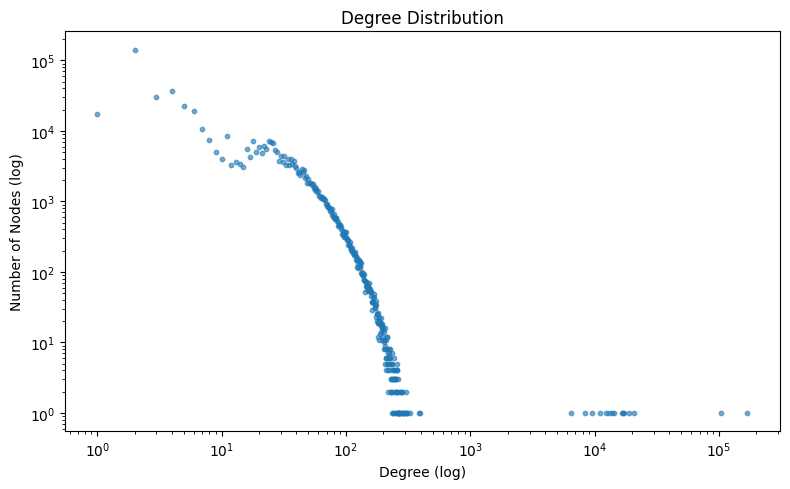

In [18]:
# PLOT DISTRIBUTION
# NOTE: toPandas() required for matplotlib (single-node library).
# Safe here as degree_distribution is pre-aggregated — at most one row per unique
# degree value, which is bounded by the max degree in the graph (~170k rows worst case).
# At scale: pre-aggregate further (e.g. bin degrees) before collecting.
degree_pd = degree_distribution.orderBy("degree").toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(degree_pd["degree"], degree_pd["count"], alpha=0.6, s=10)
plt.yscale("log")
plt.xscale("log")  # log-log é o standard para degree distribution
plt.xlabel("Degree (log)")
plt.ylabel("Number of Nodes (log)")
plt.title("Degree Distribution")
plt.tight_layout()
plt.show()

The graph shows a clear downward trend in log-log scale, confirming that the network follows a power law: the vast majority of accounts have very low degree (left side, high count) while a tiny number of accounts act as extreme hubs (right side, isolated dots).

The two isolated points on the far right (degree ~10k and ~170k) are the two suspicious accounts were already identified in the EDA, they are so far from the rest of the distribution that they stand out immediately, even visually.

The "knee" around degree 200-300 where the count drops to near 1 shows a clear separation between normal accounts and potential hub accounts. Accounts to the right of the knee exhibit anomalous degree values that are inconsistent with typical financial behavior and warrant further investigation. These accounts are strong candidates for money laundering activity, which will be validated against the is_laundering label in subsequent analyses.

In [19]:
# AVERAGE DEGREE, IN-DEGREE AND OUT-DEGREE BY LAUNDERING VS NON-LAUNDERING ACCOUNTS

account_metrics \
    .withColumn("is_suspicious", F.when(F.col("total_laundering") > 0, 1).otherwise(0)) \
    .groupBy("is_suspicious") \
    .agg(
        F.round(F.mean("inDegree"), 2).alias("avg_inDegree"),
        F.round(F.mean("outDegree"), 2).alias("avg_outDegree"),
        F.round(F.mean("degree"), 2).alias("avg_degree"),
        F.percentile_approx("degree", 0.95).alias("p95_degree")
    ) \
    .show()
    
# is suspicious if it has at least one transaction received or sent that is money laundering

+-------------+------------+-------------+----------+----------+
|is_suspicious|avg_inDegree|avg_outDegree|avg_degree|p95_degree|
+-------------+------------+-------------+----------+----------+
|            1|       16.07|        86.68|    102.75|       102|
|            0|        9.78|          8.9|     18.68|        70|
+-------------+------------+-------------+----------+----------+



The results show a clear structural difference between suspicious and non-suspicious accounts in the transaction graph.

Suspicious accounts (`is_suspicious = 1`) have substantially higher connectivity than non-suspicious accounts across all degree metrics.

The strongest difference is observed in **out-degree**, where suspicious accounts send transactions to significantly more counterparties on average. This suggests that suspicious nodes behave primarily as **senders**, distributing funds across many destinations.

This pattern is consistent with common money laundering behaviours such as:
- rapid movement of funds,
- splitting transactions across multiple accounts (*smurfing*),
- or using intermediary accounts to disperse money through the network.

Overall, the degree analysis indicates that **transaction connectivity, especially out-degree, is a strong signal for identifying suspicious accounts** in the graph.

In [20]:
# CREATE HUBS
hubs = account_metrics.orderBy(F.desc("degree")).cache()

print("TOP 10 HUBS (high total degree):")
hubs.show(10, truncate=False)

TOP 10 HUBS (high total degree):


+------------+----+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|id          |bank|degree|inDegree|outDegree|total_sent|laundering_sent|total_received|laundering_received|pct_laundering_sent|pct_laundering_received|total_laundering|total_transactions|pct_laundering_total|
+------------+----+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|70_100428660|70  |169756|1084    |168672   |168672    |243            |1084          |0                  |0.14               |0.0                    |243             |169756            |0.14                |
|70_1004286A8|70  |103671|653     |103018   |103018    |158            |653           |0                  |0.15               |0.0                    |158          

In [21]:
# ORDER HUBS BY TOTAL DEGREE AND EVALUATE LAUDERING RATES
hubs.orderBy(F.desc("degree")).show(20, truncate=False)

+--------------+----+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|id            |bank|degree|inDegree|outDegree|total_sent|laundering_sent|total_received|laundering_received|pct_laundering_sent|pct_laundering_received|total_laundering|total_transactions|pct_laundering_total|
+--------------+----+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|70_100428660  |70  |169756|1084    |168672   |168672    |243            |1084          |0                  |0.14               |0.0                    |243             |169756            |0.14                |
|70_1004286A8  |70  |103671|653     |103018   |103018    |158            |653           |0                  |0.15               |0.0                    |158

The hub analysis reveals a clear and consistent pattern across the top accounts by total degree.

All top hubs belong to **bank 70**, which was already identified in the EDA as the most active 
bank in the dataset. These accounts act as **pure senders**: they distribute tens of thousands 
of transactions outward but receive no laundering transactions, suggesting they play a 
**distribution role** in the laundering network, receiving funds upstream and dispersing them 
across many destinations.

The laundering rate across all bank 70 hubs is remarkably uniform, hovering around **0.11–0.17%**. 
This consistency is not coincidental, it suggests a deliberate strategy of **transaction 
dilution**: embedding a small, controlled proportion of illicit transactions within a much larger 
volume of legitimate ones to avoid detection by simple threshold-based rules.

The account `70_100428660`, the most connected node in the entire graph with 169,756 total 
transactions, sent **243 laundering transactions**, the highest absolute count in the top 20. 
Despite its low laundering rate (0.14%), the sheer volume makes it the single largest contributor 
to laundering activity by absolute count, confirming that **percentage alone is insufficient** 
as a detection signal.

The only exception is account `28_8000B8AB0`, from a different bank, which shows a 
**laundering rate of 4.74%**, significantly higher than all bank 70 accounts. Although its 
total degree (312) is far lower, its elevated rate suggests a different behavioral profile: 
a smaller, more concentrated node where illicit transactions represent a meaningful share of 
activity rather than being diluted by volume. It is also the only account that receives ilicit transactions in the top 20.

Overall, these results reinforce that effective hub detection requires combining both absolute 
laundering counts and laundering rates, as high-volume dilution and low-volume concentration 
represent two distinct laundering strategies within the same network.

# <font color='#2f94d7' size=5>**6.3. Suspicious Accounts**</font> <a class="anchor" id="6_3"></a>

[Back to TOC](#toc)

In [23]:
# ORDER HUBS BY TOTAL LAUNDERING AND EVALUATE LAUDERING RATES
hubs.orderBy(F.desc("total_laundering")).show(20, truncate=False)

+----------------+------+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|id              |bank  |degree|inDegree|outDegree|total_sent|laundering_sent|total_received|laundering_received|pct_laundering_sent|pct_laundering_received|total_laundering|total_transactions|pct_laundering_total|
+----------------+------+------+--------+---------+----------+---------------+--------------+-------------------+-------------------+-----------------------+----------------+------------------+--------------------+
|70_100428660    |70    |169756|1084    |168672   |168672    |243            |1084          |0                  |0.14               |0.0                    |243             |169756            |0.14                |
|70_1004286A8    |70    |103671|653     |103018   |103018    |158            |653           |0                  |0.15               |0.0    

The top two positions are still occupied by bank 70 accounts (`70_100428660` and `70_1004286A8`),
which dominate by sheer volume, 243 and 158 laundering transactions respectively. However, as 
observed before, their laundering rates remain extremely low (0.14–0.15%) and their 
`laundering_received` is 0, confirming their role as **pure senders** that dilute illicit 
transactions within massive legitimate volume.

Beyond these two, the picture changes entirely. The remaining accounts come from **diverse banks**
and exhibit a completely different behavioral profile: small total degree (41–173 transactions) 
but extremely high laundering rates, ranging from **29% to 95%**. These are not high-volume 
dilution nodes, they are **concentrated laundering accounts** where the majority of activity 
is illicit.

A key distinction from the bank 70 hubs is that these accounts show significant 
`laundering_received` values alongside `laundering_sent`. Account `119_812A09CF0`, for example, 
has a `pct_laundering_received` of 95%, meaning virtually every transaction it receives is 
flagged as laundering. These accounts are embedded **within the laundering chain itself**, both 
receiving and forwarding illicit funds, rather than sitting at the periphery as distributors.

This reveals two structurally distinct roles within the laundering network:

- **Volume distributors** (bank 70): extremely high degree, low laundering rate, zero laundering 
received: sitting at the **placement layer**, introducing illicit funds into the network by 
embedding them within massive legitimate transaction volume to avoid detection.
- **Concentrated intermediaries** (other banks): low degree, very high laundering rate on both 
sent and received: acting as **layering nodes**, receiving already-flagged funds and forwarding 
them through the network.

This distinction would be invisible if hubs were ranked purely by structural degree, reinforcing 
that combining graph topology with laundering labels is essential for meaningful AML analysis.

In [22]:
# EXPLORE RELATIONSHIP BETWEEN THE 2 TYPES OF HUBS
# Suspicious accounts with high percentage of laundering transactions (concentrated intermediaries)
suspicious_accounts = [
    "48309_811C599A0", "15231_80266F880", "23691_8021353D0", 
    "119_811C597B0", "150240_812D22980", "119_812A09CF0"
]

# Volume distributors
distributors = ["70_100428660", "70_1004286A8"]

# Check if there are direct transactions between the distributors and the concentrated intermediaries
# Check if there are direct transactions between the distributors and the concentrated intermediaries

edges_base \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(distributors)) \
    .filter(F.col("dst").isin(suspicious_accounts)) \
    .groupBy("src", "dst") \
    .agg(F.count("*").alias("laundering_transactions")) \
    .orderBy(F.desc("laundering_transactions")) \
    .show()


+---+---+-----------------------+
|src|dst|laundering_transactions|
+---+---+-----------------------+
+---+---+-----------------------+



In [24]:
# ANALYSE IF THERE IS ANOTHER INTERMEDIARY NODE BETWEEN THE 2 TYPES OF HUBS
# 1. To which accounts do the distributors send ilicit transactions to
step1 = edges_base \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(distributors)) \
    .select(F.col("dst").alias("intermediary")) \
    .distinct()

# 2. From those nodes, which send ilicit transactions to the suspicious accounts
(
    edges_base
    .filter(F.col("is_laundering") == 1)
    .join(step1, edges_base["src"] == step1["intermediary"], how="inner")
    .filter(F.col("dst").isin(suspicious_accounts))
    .groupBy("intermediary", "dst")
    .agg(F.count("*").alias("laundering_transactions"))
    .orderBy(F.desc("laundering_transactions"))
    .show()
)

+------------+---+-----------------------+
|intermediary|dst|laundering_transactions|
+------------+---+-----------------------+
+------------+---+-----------------------+



To investigate whether the volume distributors feed directly into the high-rate laundering 
accounts, edges were filtered to find laundering transactions connecting these two groups. 
Both direct connections (depth 1) and two-hop paths (depth 2) returned empty results, meaning 
no direct or near-direct link was found between the two account groups.

This suggests the laundering chain between these accounts spans more than 2 hops, indicating 
a deliberately complex layering structure designed to obscure the origin of funds. Tracing 
these paths manually becomes impractical, which motivates the use of GraphFrames' BFS 
algorithm in a later section to automatically traverse the network and uncover the full 
connection depth.

In [25]:
# ANALYSE TRANSACTIONS STARTING IN THE 2 DISTRIBUTORS
distributor_transactions = (
    edges_base
    .filter(F.col("src").isin(distributors))
    .groupBy("src", "dst")
    .agg(
        F.count("*").alias("total_transactions"),
        F.sum(F.col("is_laundering").cast("long")).alias("laundering_transactions")
    )
    .withColumn(
        "pct_laundering",
        F.when(
            F.col("total_transactions") > 0,
            F.round(F.col("laundering_transactions") / F.col("total_transactions") * 100, 2)
        ).otherwise(F.lit(0.0))
    )
)

# Order by total transactions
distributor_transactions.orderBy(F.desc("total_transactions")).show(20)

# Order by laundering transactions
distributor_transactions.orderBy(F.desc("laundering_transactions")).show(20)

+------------+----------------+------------------+-----------------------+--------------+
|         src|             dst|total_transactions|laundering_transactions|pct_laundering|
+------------+----------------+------------------+-----------------------+--------------+
|70_100428660| 15723_8041966C0|                51|                      0|           0.0|
|70_100428660|  2627_800FFA480|                51|                      0|           0.0|
|70_1004286A8|111141_8048CD220|                51|                      0|           0.0|
|70_100428660| 15447_80EA74E90|                51|                      0|           0.0|
|70_1004286A8|  3123_801E58150|                51|                      0|           0.0|
|70_100428660| 15916_807A6EE90|                44|                      0|           0.0|
|70_1004286A8| 13862_807463890|                44|                      0|           0.0|
|70_1004286A8|  4600_804983930|                44|                      0|           0.0|
|70_100428

+------------+----------------+------------------+-----------------------+--------------+
|         src|             dst|total_transactions|laundering_transactions|pct_laundering|
+------------+----------------+------------------+-----------------------+--------------+
|70_100428660|  1124_80087FCB0|                14|                      2|         14.29|
|70_1004286A8|139216_813ED5D40|                20|                      2|          10.0|
|70_100428660| 28733_81108E620|                21|                      2|          9.52|
|70_100428660|123102_80D2ACC90|                30|                      2|          6.67|
|70_100428660|  1362_800CEA850|                30|                      2|          6.67|
|70_100428660|219184_80C0D8D70|                21|                      2|          9.52|
|70_100428660| 53160_813908380|                30|                      2|          6.67|
|70_1004286A8|  8074_8077BD6A0|                20|                      2|          10.0|
|70_100428

Analysing the destination diversity of the top two distributors confirms the smurfing hypothesis. 
Despite sending hundreds of thousands of transactions, no single destination receives more than 
51 total transactions, and laundering transactions are capped at 2 per destination pair. The 243 
laundering transactions from `70_100428660` are therefore spread across at least 120 distinct 
destination accounts, making pattern detection by simple transaction monitoring effectively 
impossible.

This extreme dispersal also explains why none of the high-rate laundering accounts identified 
earlier appear as direct destinations, the distributors deliberately fragment the flow before 
it reaches the layering nodes, requiring graph traversal beyond depth 1 to reconstruct the 
full laundering chain.

# <font color='#2f94d7' size=5>**6.4. Page Rank**</font> <a class="anchor" id="6_4"></a>

[Back to TOC](#toc)

The core idea is: **a node is important if it is connected to other important nodes.**

Concretely, the algorithm works in rounds:

1. Every node starts with the same score (1/N, where N is the total number of nodes)
2. In each iteration, every node distributes its current score equally across all its outgoing edges
3. Each node's new score is the sum of what it received from its incoming edges, plus a small base amount from the random jump factor
4. Repeat for `maxIter` iterations

**Degree** simply counts how many edges touch a node. A node with 100 connections always has degree 100, regardless of whether those connections come from isolated nodes or from major hubs.

**PageRank** accounts for the quality of connections.


In [26]:
sc.setCheckpointDir("/tmp/graphframes-checkpoints-pr")

spark.conf.set("spark.sql.shuffle.partitions", "200")

pagerank_vertices = g.pageRank(resetProbability=0.15, maxIter=10).vertices.select("id", "pagerank")

pagerank_full = (
    vertices_base
    .join(pagerank_vertices, on="id", how="left")
    .fillna({"pagerank": 0.0})
)

pagerank_full.orderBy(F.desc("pagerank")).show(20, truncate=False)

26/06/03 17:10:33 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/03 17:10:33 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/03 17:10:33 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/03 17:10:33 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/03 17:11:40 WARN PageRank: Returned DataFrame is persistent and materialized!


+----------------+------+------------------+
|id              |bank  |pagerank          |
+----------------+------+------------------+
|125633_8098EF090|125633|27.253534192719314|
|1_800D40750     |1     |22.432499113614753|
|223_811C48E10   |223   |22.110814861435667|
|115_80CCAF080   |115   |21.86077819543786 |
|13145_80640B300 |13145 |21.74440913183446 |
|148785_8127E8FD0|148785|21.571144379278206|
|245748_81152BF90|245748|21.166947316617257|
|1362_800393E30  |1362  |21.04068824191088 |
|14277_80B847A90 |14277 |20.93203786811935 |
|220_800E97810   |220   |20.745745283032228|
|6_804AB4820     |6     |20.46598221965343 |
|1547_81484C700  |1547  |20.44872810224119 |
|17401_810441580 |17401 |20.205017405645513|
|3_80E6E1760     |3     |19.348323627762596|
|23370_813875370 |23370 |19.277697235185475|
|8539_80B9F5E40  |8539  |18.926731557789928|
|19474_80FEACBA0 |19474 |18.61014728589581 |
|212_8120901A0   |212   |18.53639778231372 |
|40653_80F08D3F0 |40653 |18.49031238075453 |
|12963_80A

In [33]:
print("Vertices in graph:", vertices_base.count())
print("Vertices returned by PageRank:", pagerank_vertices.count())

pagerank_missing = vertices_base.join(pagerank_vertices, on="id", how="left_anti")
print("Vertices missing from PageRank:", pagerank_missing.count())

Vertices in graph: 515088
Vertices returned by PageRank: 133928


Vertices missing from PageRank: 381160


In [ ]:
# ANALYSE RELATIONSHIP BETWEEN PAGE RANK AND MONEY LAUNDERING
# Laundering ratio for sent transactions

# Join everything onto PageRank results
top20_pr = (
    pagerank_full
    .join(account_metrics, on="id", how="left")
    .orderBy(F.desc("pagerank"))
    .limit(20)
)

top20_pr.select(
    "id",
    "pagerank",
    "total_sent",   "laundering_sent"  ,   "pct_laundering_sent",
    "total_received",   "laundering_received", "pct_laundering_received",
    "total_transactions","pct_laundering_total"
).show(20, truncate=False)

+----------------+------------------+----------+---------------+-------------------+--------------+-------------------+-----------------------+------------------+--------------------+
|id              |pagerank          |total_sent|laundering_sent|pct_laundering_sent|total_received|laundering_received|pct_laundering_received|total_transactions|pct_laundering_total|
+----------------+------------------+----------+---------------+-------------------+--------------+-------------------+-----------------------+------------------+--------------------+
|4726_808FAF7C0  |25.972973515485595|1         |0              |0.0                |90            |0                  |0.0                    |91                |0.0                 |
|12_800326F20    |25.041383171540016|4         |0              |0.0                |81            |0                  |0.0                    |85                |0.0                 |
|112931_805632690|22.231016389209348|1         |0              |0.0             

Unlike degree, PageRank shows no correlation with laundering activity. The top-ranked accounts 
by PageRank have zero laundering transactions on both sent and received sides, indicating they 
are legitimate high-connectivity nodes at the centre of the broader transaction network.

This contrast with the degree analysis is explained by the nature of PageRank itself: a node 
accumulates high PageRank by receiving transactions from other high-PageRank nodes. The top 
laundering accounts, despite their massive out-degree, have very low in-degree, `70_100428660` 
receives from only 1,084 counterparties, and those sources are unlikely to be well-connected 
legitimate nodes. Their influence is therefore local and directional, making them invisible 
to a metric that rewards global, reciprocal connectivity.

Additionaly, GraphFrames PageRank did not return scores for all vertices in this environment, so the metric was not considered reliable for the full-network analysis.

# <font color='#2f94d7' size=5>**6.5. Connected Components**</font> <a class="anchor" id="6_5"></a>

[Back to TOC](#toc)

A connected component is a group of nodes connected by some path.

If two nodes are in the same connected component, it means there is a route between them through the graph. 

In [34]:
# CREATE CONNECTED COMPONENTS
# Recreate the graph without self-loops
edges_no_selfloops = edges_base.filter(F.col("src") != F.col("dst"))

g_cc = GraphFrame(vertices_base, edges_no_selfloops)

cc = g_cc.connectedComponents().select("id", "component")

cc.cache()

print(f"CC count: {cc.count():,}")

26/06/03 17:54:59 WARN ConnectedComponents$: Returned DataFrame is persistent and materialized!


CC count: 515,088


In [35]:
# Count the number of accounts in each component
cc.groupBy("component") \
  .agg(F.count("*").alias("num_accounts")) \
  .orderBy(F.desc("num_accounts")) \
  .show(10)

+------------+------------+
|   component|num_accounts|
+------------+------------+
|           0|      372089|
|  8589934911|          24|
|         529|          23|
|292057776227|          12|
| 17179871296|          11|
|163208757280|          11|
|523986011248|          11|
|         696|          10|
|120259086094|          10|
|  8589935271|          10|
+------------+------------+
only showing top 10 rows



In [36]:
print(f"Total components: {cc.select('component').distinct().count():,}")

Total components: 114,139


Component `0` is by far the largest one with 372089 accounts. The second biggest component is ~15 500 times smaller than the first one. The data contains ~515,000 accounts so all components are very small except for the first one. Lets investigate if the suspicous accounts detected earlier are in this big component, and analyse which components have more ilicit transactions.

In [37]:
# CHECK IF THE BIGGEST COMPONENTS HAVE SUSPICOUS ACTIVITY
# Calculates the number of laundering transactions in each component, as well as the number of sent and received illicit
# transactions
cc.join(
    account_metrics.select("id","laundering_sent", "laundering_received","total_laundering"), on="id",how="left"
).fillna(0) \
 .groupBy("component") \
 .agg(
     F.count("*").alias("num_accounts"),
     F.sum("total_laundering").alias("total_laundering"),
     F.sum("laundering_sent").alias("total_laundering_sent"),
     F.sum("laundering_received").alias("total_laundering_received")
 ).orderBy(F.desc("total_laundering")) \
 .show(10)

+-------------+------------+----------------+---------------------+-------------------------+
|    component|num_accounts|total_laundering|total_laundering_sent|total_laundering_received|
+-------------+------------+----------------+---------------------+-------------------------+
|            0|      372089|           10338|                 5169|                     5169|
|1236950582194|           3|               4|                    2|                        2|
| 257698039656|           3|               2|                    1|                        1|
| 120259086041|           4|               2|                    1|                        1|
|  25769806311|           4|               2|                    1|                        1|
| 489626272544|           2|               2|                    1|                        1|
| 446676599004|           3|               2|                    1|                        1|
|1563368097160|           2|               2|               

Out of the 114,139 components, only 8 have ilicit transactions, with component `0` having almost all of them. This shows that the laundering transactions are concentrated in a single network, which is also the biggest one.

In [38]:
all_suspicious = distributors + suspicious_accounts

cc.filter(F.col("id").isin(all_suspicious)) \
  .select("id", "component") \
  .show()

+----------------+---------+
|              id|component|
+----------------+---------+
|   119_811C597B0|        0|
|    70_1004286A8|        0|
| 15231_80266F880|        0|
|150240_812D22980|        0|
| 23691_8021353D0|        0|
|    70_100428660|        0|
| 48309_811C599A0|        0|
|   119_812A09CF0|        0|
+----------------+---------+



As expected all the suspicious accounts are in component `0`, it is very likely that the money sent by the distributors will reach the intermediary accounts, with the next analysis this will be investigated.

In [39]:
cc.unpersist()

DataFrame[id: string, component: bigint]

# <font color='#2f94d7' size=5>**6.6. Breadth-first search (BFS)**</font> <a class="anchor" id="6_6"></a>

[Back to TOC](#toc)

Given a starting node, it visits all neighbours one hop away, then all neighbours two hops away, and so on, expanding outward in concentric "rings" of distance from the source. It stops either when the entire reachable graph has been explored or when a target condition is met. 

For this case we do not have interest in creating an undirected graph, as the goal is to follow the chain that starts in the 2 distributors.

In [60]:
# FIND THE PATH BETWEEN THE DISTRIBUTORS AND THE INTERMEDIARIES
for distributor in distributors:
    print(f"\nBFS from {distributor}:")
    result = g.bfs(
        fromExpr   = f"id = '{distributor}'",
        toExpr     = "id IN ('" + "', '".join(suspicious_accounts) + "')",
        edgeFilter = "is_laundering = 1",
        maxPathLength = 20
    )
    print(f"Paths found: {result.count()}")
    result.show(5, truncate=False)


BFS from 70_100428660:


26/06/02 23:00:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Paths found: 0
+---+----+
|id |bank|
+---+----+
+---+----+


BFS from 70_1004286A8:


Paths found: 0
+---+----+
|id |bank|
+---+----+
+---+----+



BFS was applied to trace laundering paths from the two volume distributors to the 
concentrated intermediaries identified in section 6.3, following exclusively edges 
flagged as laundering transactions up to a maximum depth of 20 hops.

Both searches returned zero paths, confirming that no laundering chain connects these 
two account groups. Despite belonging to the same connected component, the distributors 
and the concentrated intermediaries operate as **two independent laundering clusters** 
within the network, with no illicit flow between them.

This suggests the dataset captures at least two structurally distinct laundering schemes 
running in parallel: a high-volume dilution pattern centred on bank 70, and a concentrated 
layering pattern across multiple smaller banks, each operating in isolation from the other.

In [42]:
# INVESTIGATE THE 2 LAUNDERING SCHEMES
# 
print("Where do distributors send laundering transactions?")
g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(distributors)) \
    .groupBy("dst") \
    .agg(F.count("*").alias("laundering_transactions")) \
    .orderBy(F.desc("laundering_transactions")) \
    .show(20)

print("Examples of laundering transactions sent by the distributors:")
g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(distributors)) \
    .select("src", "dst", "amount_usd") \
    .orderBy("amount_usd", ascending = False) \
    .show(10)


print("Where do suspicious accounts receive laundering from?")
g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("dst").isin(suspicious_accounts)) \
    .groupBy("src") \
    .agg(F.count("*").alias("laundering_transactions")) \
    .orderBy(F.desc("laundering_transactions")) \
    .show(20)

print("Examples of laundering transactions received by the suspicious accounts:")
g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("dst").isin(suspicious_accounts)) \
    .select("src", "dst", "amount_usd") \
    .orderBy("amount_usd", ascending = False) \
    .show(10)

Where do distributors send laundering transactions?
+----------------+-----------------------+
|             dst|laundering_transactions|
+----------------+-----------------------+
|123102_80D2ACC90|                      2|
|219184_80C0D8D70|                      2|
|122151_81112BB40|                      2|
|  1362_800CEA850|                      2|
|  1124_80087FCB0|                      2|
| 28733_81108E620|                      2|
|139216_813ED5D40|                      2|
| 53160_813908380|                      2|
|  8074_8077BD6A0|                      2|
|  2627_8015F56C0|                      1|
|117299_80BB9E670|                      1|
| 12963_80233B5D0|                      1|
|  4726_806C6A5F0|                      1|
| 12979_807CEBAF0|                      1|
| 21174_805AE5230|                      1|
|247368_8145D4C50|                      1|
| 24515_804E33730|                      1|
| 11107_8042948D0|                      1|
|215064_810AE3EA0|                      1|
|1

+------------+----------------+-------------+
|         src|             dst|   amount_usd|
+------------+----------------+-------------+
|70_100428660|   220_805822770|2.003000028E7|
|70_1004286A8|142501_812DA8900|1.545485465E7|
|70_100428660|113798_80DC756E0|1.317142553E7|
|70_1004286A8| 31149_813FDB660|1.315580719E7|
|70_100428660| 21940_802C641F0|   7082650.61|
|70_100428660|123102_80D2ACC90|   2314294.52|
|70_100428660| 30775_80F2F7770|   1790434.47|
|70_100428660|  2845_80115AE30|    939548.06|
|70_1004286A8|  5365_80B912520|     885157.8|
|70_100428660|219184_80C0D8D70|    827659.73|
+------------+----------------+-------------+
only showing top 10 rows

Where do suspicious accounts receive laundering from?


+----------------+-----------------------+
|             src|laundering_transactions|
+----------------+-----------------------+
| 15231_80266F880|                     29|
| 23691_8021353D0|                     21|
| 49365_812A09D40|                     18|
|150240_812D22980|                     18|
| 48309_811C599A0|                     18|
|   222_811B83280|                     17|
|   119_811C597B0|                     14|
|   119_812A09CF0|                      1|
+----------------+-----------------------+

Examples of laundering transactions received by the suspicious accounts:


+----------------+----------------+-------------+
|             src|             dst|   amount_usd|
+----------------+----------------+-------------+
| 48309_811C599A0|150240_812D22980|3.873586285E7|
|   119_811C597B0| 48309_811C599A0|    6806135.7|
| 48309_811C599A0|   119_811C597B0|   5676114.64|
|   119_811C597B0|   119_811C597B0|   3768531.78|
|150240_812D22980| 48309_811C599A0|     19746.36|
|150240_812D22980|150240_812D22980|     19109.74|
|   222_811B83280| 48309_811C599A0|     18912.46|
| 49365_812A09D40|   119_812A09CF0|     18756.56|
|   222_811B83280| 48309_811C599A0|     18626.47|
|150240_812D22980| 48309_811C599A0|     18542.29|
+----------------+----------------+-------------+
only showing top 10 rows



In [43]:
print(suspicious_accounts)

['48309_811C599A0', '15231_80266F880', '23691_8021353D0', '119_811C597B0', '150240_812D22980', '119_812A09CF0']


In [44]:
# WHERE DO THE SUSPICOUS ACCOUNTS SEND MONEY TO ?
print("Where do the suspicious accounts send money to?")
edges_base \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(suspicious_accounts)) \
    .groupBy("dst") \
    .agg(F.count("*").alias("laundering_transactions")) \
    .orderBy(F.desc("laundering_transactions")) \
    .show(20)

Where do the suspicious accounts send money to?


+----------------+-----------------------+
|             dst|laundering_transactions|
+----------------+-----------------------+
| 23691_8021353D0|                     28|
| 48309_811C599A0|                     24|
| 15231_80266F880|                     22|
|   119_811C597B0|                     18|
|   222_811B83280|                     17|
| 49365_812A09D40|                     15|
|150240_812D22980|                      8|
|   119_812A09CF0|                      1|
+----------------+-----------------------+



In [46]:
# INVESTIGATE THE 2 EXTERNAL ACCOUNTS
# Accounts to where the suspicous accounts send ilicit money, that are not themselves
print("Ilicit transactions from the suspicious accounts to the external accounts")
external_destinations = g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(suspicious_accounts)) \
    .filter(~F.col("dst").isin(suspicious_accounts)) \
    .select("src", "dst", "amount_usd")

external_destinations.show()

# Characterise the external accounts
# NOTE: collect() brings IDs to the driver for isin() filtering.
# Safe here as both lists contain fewer than 10 IDs.
# At scale: replace with a distributed join against the source DataFrame.
external_ids = [row["dst"] for row in external_destinations.select("dst").distinct().collect()]

print("Transactions from the external accounts")
g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(external_ids)) \
    .groupBy("src", "dst") \
    .agg(F.count("*").alias("laundering_transactions")) \
    .show()

Ilicit transactions from the suspicious accounts to the external accounts
+----------------+---------------+----------+
|             src|            dst|amount_usd|
+----------------+---------------+----------+
|   119_811C597B0|  222_811B83280|    192.89|
|   119_812A09CF0|49365_812A09D40|   7908.65|
|150240_812D22980|  222_811B83280|  14365.99|
|   119_812A09CF0|49365_812A09D40|  14531.21|
|   119_811C597B0|  222_811B83280|   6429.93|
|   119_812A09CF0|49365_812A09D40|   2685.24|
|150240_812D22980|  222_811B83280|   1611.03|
|   119_812A09CF0|49365_812A09D40|   7076.29|
|   119_812A09CF0|49365_812A09D40|   5098.69|
|   119_811C597B0|  222_811B83280|   8345.57|
| 48309_811C599A0|  222_811B83280|   9508.17|
|   119_812A09CF0|49365_812A09D40|   3108.62|
|150240_812D22980|  222_811B83280|  12873.22|
|150240_812D22980|  222_811B83280|   7550.94|
| 48309_811C599A0|  222_811B83280|   9277.54|
|   119_811C597B0|  222_811B83280|   1573.35|
|   119_812A09CF0|49365_812A09D40|     54.83|
|15024

Transactions from the external accounts
+---------------+----------------+-----------------------+
|            src|             dst|laundering_transactions|
+---------------+----------------+-----------------------+
|  222_811B83280| 48309_811C599A0|                      7|
|49365_812A09D40|   119_812A09CF0|                     18|
|  222_811B83280|   119_811C597B0|                      5|
|  222_811B83280|150240_812D22980|                      5|
+---------------+----------------+-----------------------+



Further investigation confirmed that the two groups operate as fully independent clusters. 
The distributors send laundering transactions exclusively to external accounts not present 
in either group, with a maximum of 2 transactions per destination, consistent with the 
smurfing pattern identified earlier.

The concentrated intermediaries form a **near-closed circuit**: the vast majority of 
laundering inflows originate from within the same group of suspicious accounts. Two external 
accounts (`222_811B83280` and `49365_812A09D40`) also participate in the cycle, receiving 
laundering transactions from the group and sending them back in return, effectively acting 
as peripheral nodes that extend the circuit without breaking it. This is a classic layering 
pattern where funds are cycled repeatedly to obscure their origin before eventual extraction.

These two clusters represent structurally and operationally distinct laundering schemes 
with no intersection, confirming that graph topology alone, without laundering labels, 
would be insufficient to detect either pattern.

In [47]:
# FURTHER EXPLORE THE NETWORK THAT STARTS IN THE 2 DISTRIBUTORES
# Accounts that receive directly from the distributors (only ilicit transactions)
direct_destinations = (
    g.edges
    .filter(F.col("is_laundering") == 1)
    .filter(F.col("src").isin(distributors))
    .groupBy(F.col("dst").alias("id"))
    .agg(F.round(F.mean("amount_usd"), 2).alias("avg_amount"))
)

print(f"Direct destinations: {direct_destinations.count()}")


direct_destinations \
    .join(
        account_metrics.select(
            "id",
            "total_sent", "laundering_sent", "pct_laundering_sent",
            "total_received", "laundering_received", "pct_laundering_received",
            "total_laundering"
        ),
        on="id",
        how="left"
    ) \
    .fillna(0) \
    .agg(
        F.count("*").alias("total_accounts"),
        F.sum(F.when(F.col("laundering_sent") > 0, 1).otherwise(0)).alias("accounts_that_resend"),
        F.sum(F.when(F.col("laundering_sent") == 0, 1).otherwise(0)).alias("pure_receivers"),
        F.round(F.mean("total_laundering"), 2).alias("avg_laundering"),
        F.round(F.mean("pct_laundering_sent"), 2).alias("avg_pct_sent"),
        F.round(F.mean("avg_amount"), 2).alias("avg_amount")
    ) \
    .show()


Direct destinations: 392


+--------------+--------------------+--------------+--------------+------------+----------+
|total_accounts|accounts_that_resend|pure_receivers|avg_laundering|avg_pct_sent|avg_amount|
+--------------+--------------------+--------------+--------------+------------+----------+
|           392|                   4|           388|          1.05|        0.31| 205362.28|
+--------------+--------------------+--------------+--------------+------------+----------+



In [49]:
# ANALYSE THE RESENDERS, CHECK WHERE THEY SEND THEIR ILLICIT MONEY TO
print("Information about the resenders:")

resenders = (
    direct_destinations
    .join(
        account_metrics.select(
            "id",
            "total_sent", "laundering_sent", "pct_laundering_sent",
            "total_received", "laundering_received", "pct_laundering_received"
        ),
        on="id",
        how="left"
    )
    .fillna(0)
    .filter(F.col("laundering_sent") > 0)
    .select(
        "id",
        "total_sent", "laundering_sent", "pct_laundering_sent",
        "total_received", "laundering_received", "pct_laundering_received"
    )
)

resenders.show()

print("Where do resenders send laundering money to?")

# NOTE: collect() brings resender IDs to the driver for isin() filtering.
# Safe here as resenders contains only 4 accounts.
# At scale: replace with a distributed join:
#   g.edges.filter(F.col("is_laundering") == 1)
#          .join(resenders.select(F.col("id").alias("src")), on="src", how="inner")
g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin([row["id"] for row in resenders.select("id").collect()])) \
    .groupBy("src", "dst") \
    .agg(
        F.count("*").alias("laundering_transactions"),
        F.round(F.mean("amount_usd"), 2).alias("avg_amount")
    ) \
    .show()

Information about the resenders:


+----------------+----------+---------------+-------------------+--------------+-------------------+-----------------------+
|              id|total_sent|laundering_sent|pct_laundering_sent|total_received|laundering_received|pct_laundering_received|
+----------------+----------+---------------+-------------------+--------------+-------------------+-----------------------+
|215064_810AE3EA0|         4|              1|               25.0|             8|                  1|                   12.5|
|221279_80C0D3710|         8|              1|               12.5|            28|                  2|                   7.14|
| 11107_81384AC30|         3|              1|              33.33|            35|                  1|                   2.86|
|  2591_80A1C7710|         2|              1|               50.0|            21|                  1|                   4.76|
+----------------+----------+---------------+-------------------+--------------+-------------------+-----------------------+


+----------------+----------------+-----------------------+----------+
|             src|             dst|laundering_transactions|avg_amount|
+----------------+----------------+-----------------------+----------+
|221279_80C0D3710|127999_80AD0E740|                      1|   2933.61|
|  2591_80A1C7710| 24850_80A09CF50|                      1|   3730.53|
| 11107_81384AC30|226925_81384ABE0|                      1|    560.11|
|215064_810AE3EA0| 17425_810AE3DB0|                      1|    390.45|
+----------------+----------------+-----------------------+----------+



To characterise the full reach of the distributor cluster, all direct destinations of 
laundering transactions from the two distributors were analysed. A total of **392 distinct 
accounts** receive laundering transactions from the distributors, of which **388 are pure 
receivers** that do not forward the funds further. Only 4 accounts resend laundering 
transactions.

In [51]:
# CONTINUE TO EXPLORE THE DEPTH OF THE CHAIN
final_destinations = ["127999_80AD0E740", "226925_81384ABE0", 
                      "24850_80A09CF50", "17425_810AE3DB0"]

# Check if these are still resenders
g.edges \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(final_destinations)) \
    .select("src", "dst", "amount_usd") \
    .show()

+---------------+---------------+----------+
|            src|            dst|amount_usd|
+---------------+---------------+----------+
|24850_80A09CF50|23833_8067AD0A0|   4646.02|
+---------------+---------------+----------+



There is one more ilicit transaction

In [52]:
hop4_dst = edges_base \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(final_destinations)) \
    .select(F.col("dst")).first()[0]

edges_base \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src") == hop4_dst) \
    .show()

+---+---+-------------+
|src|dst|is_laundering|
+---+---+-------------+
+---+---+-------------+



To fully characterise the laundering network originating from the two distributors, the flow 
of illicit funds was traced hop by hop until no further laundering transactions were found.

**Hop 1 — Distributors -> 392 accounts**: the two distributors disperse laundering transactions 
across 392 distinct destination accounts, each receiving on average just over 1 laundering 
transaction at an average value of ~$206,000 USD. The extreme fragmentation makes each 
individual destination account appear nearly clean, with an average laundering rate of 0.06%.

**Hop 2 — 4 resenders**: of the 392 accounts, only 4 forward a laundering transaction further. 
Each resender sends exactly 1 laundering transaction to a unique destination, with amounts 
ranging from ~$390 to ~$3,730 USD, significantly smaller than the original distributor 
transactions, suggesting the funds are being broken down further as they move through the chain.

**Hop 3 — 1 resender**: of the 4 hop-2 destinations, only 1 forwards a laundering transaction, 
again to a unique account.

**Hop 4 — terminal**: the hop-3 destination does not forward any laundering transactions, 
marking the end of the chain.

The full network structure is therefore:
2 Distributors -> 392 accounts -> 4 accounts -> 1 terminal account

This 4-hop chain, combined with progressive fragmentation of transaction amounts and extreme 
dispersal at each layer, represents a deliberate **placement and layering strategy** designed 
to make the illicit funds untraceable through conventional per-account monitoring.

# <font color='#2f94d7' size=5>**6.7. Triangle Count**</font> <a class="anchor" id="6_7"></a>

[Back to TOC](#toc)

A triangle in a graph is three nodes that are all mutually connected: every node is a neighbour of every other node in the triple. Triangle count is exactly what it sounds like — for each node, how many triangles include it? In this case, a Triangle is a group of 3 accounts where account A sends money to account B, which sends money to account C, which in turn sends money to account A. It is expected that the closed circuit mentioned in the aboce subsection will be identified.

In [53]:
# CALCULATE TRIANGLE COUNTS
# Triangle counts does not support self-loops or  directed graphs 
edges_undirected = (
    edges_no_selfloops
    .select("src", "dst")
    .union(
        edges_no_selfloops.select(
            F.col("dst").alias("src"),
            F.col("src").alias("dst")
        )
    )
    .distinct()
)

g_undirected = GraphFrame(vertices_base, edges_undirected)

triangle_counts = (
    g_undirected.triangleCount(StorageLevel.MEMORY_AND_DISK)
    .select("id", "count")
)

triangle_full = (
    vertices_base
    .join(triangle_counts, on="id", how="left")
    .fillna({"count": 0})
)

26/06/03 18:05:42 WARN AggregateMessages: Returned DataFrame is persistent and materialized!
26/06/03 18:06:17 WARN TriangleCount$: Returned DataFrame is persistent and materialized!


The top accounts are from bank 70 but they are not the 2 distributors already identified

In [54]:
triangle_full.join(
    account_metrics.select("id", "total_laundering"),
    on="id",
    how="left"
).fillna({"total_laundering": 0}) \
 .withColumn("is_suspicious", F.when(F.col("total_laundering") > 0, 1).otherwise(0)) \
 .groupBy("is_suspicious") \
 .agg(
     F.round(F.mean("count"), 2).alias("avg_triangles"),
     F.max("count").alias("max_triangles")
 ).show()

+-------------+-------------+-------------+
|is_suspicious|avg_triangles|max_triangles|
+-------------+-------------+-------------+
|            1|         0.03|           38|
|            0|         0.01|           42|
+-------------+-------------+-------------+



Triangle count shows a marginal difference between suspicious and non-suspicious accounts: 
suspicious accounts average 0.05 triangles versus 0.0 for legitimate accounts, with a 
maximum of 42 compared to 38. While suspicious accounts form slightly denser local 
structures, the difference is too small to be a meaningful detection signal.

This is consistent with the smurfing pattern identified earlier: the laundering strategy 
in this dataset is based on **dispersal across many distinct destinations**, not on forming 
dense interconnected clusters. Triangle count rewards local density, which is precisely 
what these accounts avoid by design.

Unlike degree, which clearly separates suspicious from legitimate accounts, triangle count 
provides no actionable discrimination signal in this network.

# <font color='#2f94d7' size=5>**6.8. Motif Finding**</font> <a class="anchor" id="6_8"></a>

[Back to TOC](#toc)

Motifs are small graph patterns. Instead of only ranking nodes, motif finding asks:
> Can we find this specific structure in the graph?

GraphFrames returns motif results as a DataFrame, so we can filter and summarise them with normal PySpark operations.


In [71]:
motifs_2 = g.find("(a)-[e1]->(b); (b)-[e2]->(a)") \
    .filter("e1.is_laundering = 1 AND e2.is_laundering = 1") \
    .filter("a.id != b.id") \
    .select("a.id", "b.id") \
    .distinct()

print(f"Unique 2-node cycles: {motifs_2.count()}")
motifs_2.show(10)

Unique 2-node cycles: 80


+----------------+---------------+
|              id|             id|
+----------------+---------------+
| 49365_812A09D40|  119_812A09CF0|
|   118_811B9B110|  118_811B6E170|
|   222_811D80C30|  118_811B6E170|
|   119_811DCA9B0|  118_811B6E170|
|   121_8000E1590|  118_811B6E170|
|   119_8000DB3C0|  118_811B6E170|
|   701_80408AC50| 1665_801C602A0|
| 50202_812D129C0|  222_812D127D0|
|  1665_801C602A0|  701_80408AC50|
|148350_812D0C3C0|50528_812D0C600|
+----------------+---------------+
only showing top 10 rows



In [72]:
#  FIND CYCLES OF LAUNDERING TRANSACTIONS WITH 3 NODES ( A-> B -> C -> A)
motifs_3 = g.find("(a)-[e1]->(b); (b)-[e2]->(c); (c)-[e3]->(a)") \
    .filter("e1.is_laundering = 1 AND e2.is_laundering = 1 AND e3.is_laundering = 1") \
    .filter("a.id != b.id AND b.id != c.id AND a.id != c.id") \
    .select("a.id", "b.id", "c.id") \
    .distinct()

print(f"Unique 3-node cycles: {motifs_3.count()}")
motifs_3.show(10)

Unique 3-node cycles: 162


+----------------+---------------+--------------+
|              id|             id|            id|
+----------------+---------------+--------------+
| 22828_8011150C0|21575_800EC1750|3335_8015A6530|
|   121_8000E1590|  118_811B9B110| 118_811B6E170|
|   222_811D80C30|  118_811B9B110| 118_811B6E170|
|   119_8000DB3C0|  222_811D80C30| 118_811B6E170|
|   118_811A67510|  222_811D80C30| 118_811B6E170|
|   223_811B9B160|  222_811D80C30| 118_811B6E170|
|228101_80B0C3F40|  222_811D80C30| 118_811B6E170|
|   118_812D06150|  222_811D80C30| 118_811B6E170|
|   121_8000E1590|  222_811D80C30| 118_811B6E170|
|   119_811B88600|  222_811D80C30| 118_811B6E170|
+----------------+---------------+--------------+
only showing top 10 rows



In [73]:
# FIND FANOUT ( A-> B AND A -> C)
motifs_fanout = g.find("(a)-[e1]->(b); (a)-[e2]->(c)") \
    .filter("e1.is_laundering = 1 AND e2.is_laundering = 1") \
    .filter("b.id != c.id")

print(f"Fan-out patterns with laundering: {motifs_fanout.count()}")

Fan-out patterns with laundering: 99876


Motif finding confirmed and quantified the structural patterns identified through BFS and 
edge analysis.

**2-node cycles (A->B->A):** 80 unique pairs of accounts exchange laundering transactions 
in both directions. This confirms the closed-circuit behaviour of the concentrated 
intermediary cluster, where accounts repeatedly send funds back and forth to simulate 
legitimate activity.

**3-node cycles (A->B->C->A):** 162 unique triangles of accounts form laundering cycles. 
These represent slightly more complex layering structures where funds rotate through 3 
accounts before returning to the origin, making the flow harder to trace than simple 
back-and-forth exchanges.

**Fan-out (A->B and A->C):** 99,876 patterns confirm the smurfing strategy of the 
distributor cluster, accounts systematically sending laundering transactions to multiple 
distinct destinations simultaneously, consistent with the extreme dispersal observed in 
the hop-by-hop analysis.

Together, these three motifs capture the two distinct laundering strategies present in 
the network: **cyclic layering** in the concentrated intermediary cluster and **fan-out 
dispersal** in the distributor cluster.

# <font color='#2f94d7' size=5>**6.9. Subgraph Visualization**</font> <a class="anchor" id="6_9"></a>

[Back to TOC](#toc)

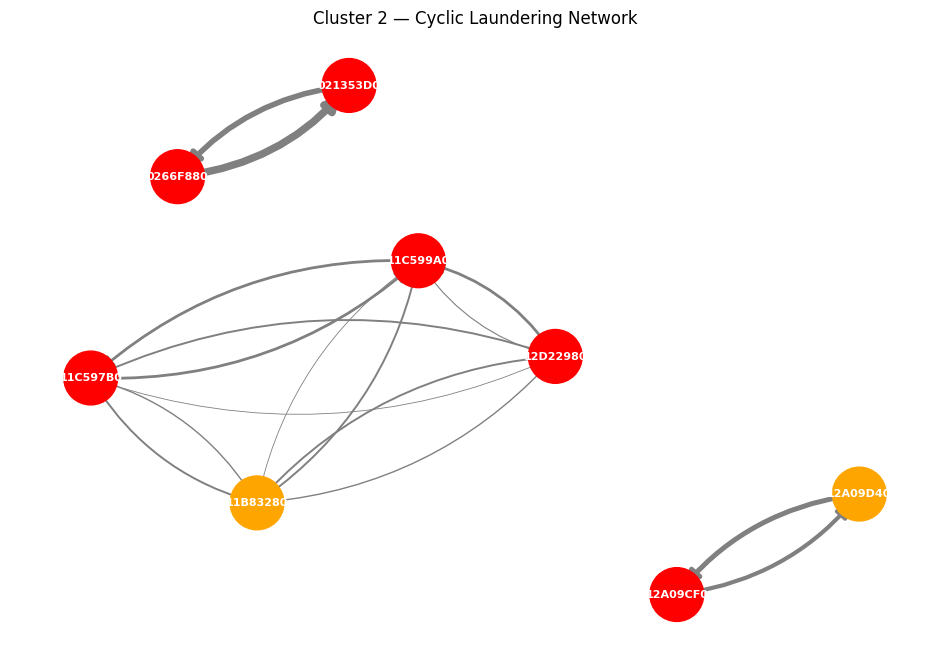

In [55]:
cycle_edges_pd = edges_base \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(suspicious_accounts + ["222_811B83280", "49365_812A09D40"])) \
    .filter(F.col("dst").isin(suspicious_accounts + ["222_811B83280", "49365_812A09D40"])) \
    .groupBy("src", "dst") \
    .agg(F.count("*").alias("weight")) \
    .toPandas()

G_cycle = nx.DiGraph()
for _, row in cycle_edges_pd.iterrows():
    G_cycle.add_edge(row["src"], row["dst"], weight=row["weight"])

G_cycle.remove_edges_from(nx.selfloop_edges(G_cycle))

labels = {n: n[-8:] for n in G_cycle.nodes()}
node_colors = [
    "red" if node in suspicious_accounts else "orange"
    for node in G_cycle.nodes()
]
# PLOT CYCLIC LAUNDERING NETWORK
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_cycle, seed=1, k=3)
nx.draw_networkx_nodes(G_cycle, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_labels(G_cycle, pos, labels=labels, font_size=8, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G_cycle, pos, arrows=True, arrowsize=20, edge_color="gray",
    width=[G_cycle[u][v]["weight"] * 0.2 for u, v in G_cycle.edges()],
    connectionstyle="arc3,rad=0.2")
plt.title(f"Cluster 2 — Cyclic Laundering Network")
plt.axis("off")
plt.show()

The cyclic laundering network (Cluster 2) reveals three structurally distinct sub-clusters 
operating independently within the same connected component.

The **central cluster** (top right) is the most active, consisting of three core accounts 
(`11C597B0`, `11C599A0`, `12D22980`) with dense bidirectional edges between them, and one 
peripheral account (`11B83280`, orange) that both sends and receives from the core group. 
The multiple edges between each pair confirm the repeated cycling of funds characteristic 
of layering behaviour.

The **upper left pair** (`0266F880` <---> `021353D0`) forms a simpler 2-node cycle, exchanging 
laundering transactions back and forth with no connection to the central cluster.

The **lower right pair** (`12A09CF0` <---> `12A09D40`) similarly forms an isolated 2-node cycle, 
with `12A09D40` (orange) acting as the peripheral node receiving from the core and cycling 
back.

The orange nodes represent the two external peripheral accounts identified earlier, they 
participate in the cycle but are not part of the core suspicious account group, extending 
the circuit without being flagged by simple account-level monitoring.

In [56]:
# PLOT SMURFING NETWORK
resenders_list = ["2591_80A1C7710", "221279_80C0D3710", "215064_810AE3EA0", "11107_81384AC30"]
hop3_list = ["127999_80AD0E740", "226925_81384ABE0", "24850_80A09CF50", "17425_810AE3DB0"]
hop4_list = ["23833_8067AD0A0"]

# Extract all laundering edges across the full 4-hop chain
# NOTE: NetworkX and pyvis require data on the driver.
# Safe here as both subgraphs are small (<400 nodes, filtered from full graph).
# At scale: use GraphX or export only a representative sample for visualization.
chain_edges = edges_base \
    .filter(F.col("is_laundering") == 1) \
    .filter(F.col("src").isin(distributors)) \
    .groupBy("src", "dst") \
    .agg(F.count("*").alias("weight")) \
    .union(
        edges_base \
            .filter(F.col("is_laundering") == 1) \
            .filter(F.col("src").isin(resenders_list)) \
            .groupBy("src", "dst") \
            .agg(F.count("*").alias("weight"))
    ) \
    .union(
        edges_base \
            .filter(F.col("is_laundering") == 1) \
            .filter(F.col("src").isin(hop3_list)) \
            .groupBy("src", "dst") \
            .agg(F.count("*").alias("weight"))
    ) \
    .toPandas()

# Build directed graph
G_dist = nx.DiGraph()
for _, row in chain_edges.iterrows():
    G_dist.add_edge(row["src"], row["dst"], weight=row["weight"])

# Interactive visualization with pyvis
net = Network(directed=True, height="600px", width="100%", notebook=True, cdn_resources='in_line')
net.from_nx(G_dist)

# Color and size nodes by their role in the laundering chain
for node in net.nodes:
    node["label"] = node["id"][-8:]  # short label for readability
    node["title"] = node["id"]       # full ID shown on hover
    if node["id"] in distributors:
        node["color"] = "red"
        node["size"] = 30
    elif node["id"] in resenders_list:
        node["color"] = "orange"
        node["size"] = 20
    elif node["id"] in hop3_list:
        node["color"] = "yellow"
        node["size"] = 15
    elif node["id"] in hop4_list:
        node["color"] = "green"
        node["size"] = 15
    else:
        node["color"] = "lightblue"
        node["size"] = 8

net.show("distributor_network.html")

distributor_network.html


This interactive visualization of the subgraph can be analysed by opening `distributor_network.html` after downloading it.

The distributor network visualises the full 4-hop laundering chain originating from the 
two volume distributors (red, centre). Each distributor sends laundering transactions to 
hundreds of terminal accounts (light blue, outer ring), with no single destination 
receiving more than 2 transactions, confirming the smurfing strategy identified in the 
graph analysis.

Four resender accounts (orange) are visible slightly further from the centre, each 
receiving one laundering transaction from a distributor and forwarding it one hop further. 
Their four hop-3 destinations (yellow) are in turn connected to a single terminal node 
(green), marking the end of the chain.

The stark visual contrast between the two distributors, two densely connected central 
nodes surrounded by hundreds of isolated terminal nodes, illustrates why degree-based 
detection is effective for this cluster: no legitimate account exhibits this structural 
pattern of extreme fan-out with uniformly low per-destination transaction counts.

In [57]:
account_metrics.unpersist()
edges_base.unpersist()

DataFrame[src: string, dst: string, is_laundering: int]

# <font color='#2f94d7' size=5>**7. Streaming**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

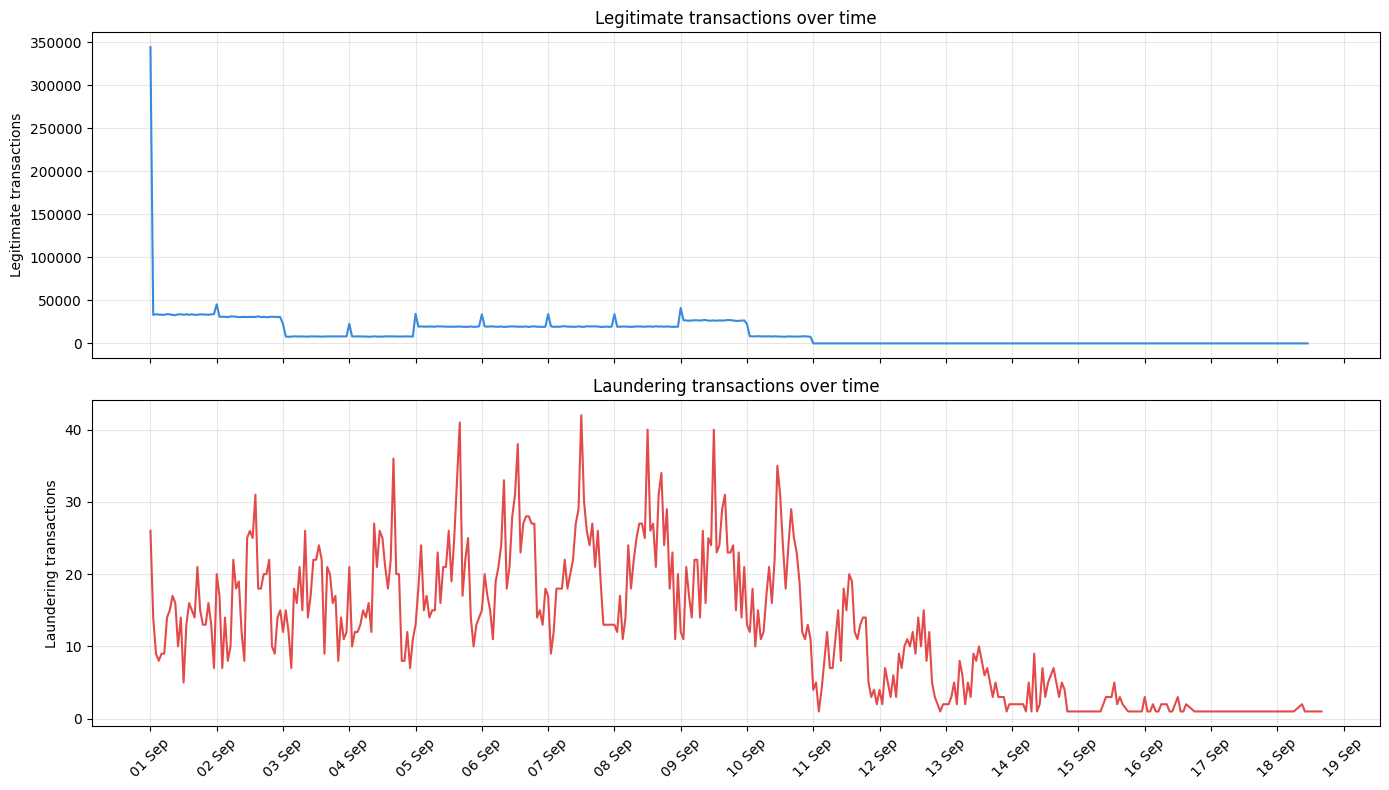

In [78]:
# PLOT THE LEGITIMATE/FRAUDULENT TRANSACTIONS ACROSS TIME
# NOTE: toPandas() required for matplotlib (single-node library).
# Safe here as the result is pre-aggregated by hour and is_laundering — at most
# 2 × 432 rows = 864 rows regardless of dataset size.
# At scale: this pattern scales well since aggregation happens in Spark before collect.
hourly = df_clean \
    .withColumn("day_hour", F.date_format("Timestamp", "yyyy-MM-dd HH")) \
    .groupBy("day_hour", "is_laundering") \
    .count() \
    .orderBy("day_hour") \
    .toPandas()

# Convert day_hour string to datetime for proper x-axis formatting
hourly["day_hour"] = pd.to_datetime(hourly["day_hour"], format="%Y-%m-%d %H")

# Separate legitimate and laundering transactions
legit   = hourly[hourly["is_laundering"] == 0].set_index("day_hour")["count"]
launder = hourly[hourly["is_laundering"] == 1].set_index("day_hour")["count"]

# Two separate subplots sharing the same x-axis
# A dual y-axis was avoided since the scale difference (~1000x) would make
# the laundering line invisible on a shared axis
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True
)

# Legitimate transactions over time
ax1.plot(legit.index, legit.values, color="#378ADD", linewidth=1.5)
ax1.set_ylabel("Legitimate transactions")
ax1.set_title("Legitimate transactions over time")
ax1.grid(alpha=0.3)

# Laundering transactions over time
ax2.plot(launder.index, launder.values, color="#E24B4A", linewidth=1.5)
ax2.set_ylabel("Laundering transactions")
ax2.set_title("Laundering transactions over time")
ax2.grid(alpha=0.3)

# Format x-axis with day labels, one tick per day
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.xaxis.set_major_locator(mdates.DayLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Both legitimate and laundering transactions decline over time, with a sharp drop after 
September 10th, a characteristic of the synthetic dataset rather than a real behavioral 
pattern. This makes absolute volume thresholds unreliable as detection signals, since the 
baseline changes continuously.

Laundering transactions do not follow the periodic rhythm of legitimate ones. While 
legitimate activity shows regular daily spikes, laundering peaks are irregular and do not 
coincide with high-volume legitimate periods, suggesting that the laundering accounts in 
this dataset make no attempt to blend into the temporal pattern of normal financial activity.

In [ ]:
STREAM_DIR = "../../data/IBM_Transactions/aml_stream"
os.makedirs(STREAM_DIR, exist_ok=True)

# Add an hour bucket column to group transactions by date and hour
df_stream = df_clean \
    .withColumn("hour_bucket", F.date_format("Timestamp", "yyyy-MM-dd_HH"))

# Get the sorted list of unique hour buckets to write files in chronological order
hours = df_stream \
    .select("hour_bucket") \
    .distinct() \
    .orderBy("hour_bucket") \
    .toPandas()["hour_bucket"].tolist()

# Write one CSV file per hour, named by date and hour (e.g. 2022-09-01_00.csv)
# ISO format ensures files are picked up by Spark in chronological order,
# simulating transactions arriving hour by hour in the streaming pipeline
# NOTE: toPandas() + to_csv() pulls data to the driver for each hour bucket.
# Acceptable here given dataset size (~13k rows/hour).
# At scale: use df.write.partitionBy("hour_bucket").csv(STREAM_DIR) instead.
for hour in hours:
    df_stream \
        .filter(F.col("hour_bucket") == hour) \
        .drop("hour_bucket") \
        .toPandas() \
        .to_csv(f"{STREAM_DIR}/{hour}.csv", index=False)

print(f"Wrote {len(os.listdir(STREAM_DIR))} files to {STREAM_DIR}/")

Wrote 385 files to ../../data/IBM_Transactions/aml_stream/


In [9]:
# Schema matching the original dataset columns
aml_schema = StructType([
    StructField("Timestamp",        TimestampType()),
    StructField("from_bank",        IntegerType()),
    StructField("src_account",      StringType()),
    StructField("to_bank",          IntegerType()),
    StructField("dst_account",      StringType()),
    StructField("amount_paid",      DoubleType()),
    StructField("pay_currency",     StringType()),
    StructField("amount_received",  DoubleType()),
    StructField("recv_currency",    StringType()),
    StructField("pay_format",       StringType()),
    StructField("is_laundering",    IntegerType()),
    StructField("src_id",           StringType()),
    StructField("dst_id",           StringType()),
    StructField("amount_usd",       DoubleType()),
])

# Read 3 file per trigger, simulating transactions arriving hour by hour
aml_stream = (
    spark.readStream
    .option("maxFilesPerTrigger", 3)
    .option("header", True)
    .format("csv")
    .schema(aml_schema)
    .load("../../data/IBM_Transactions/aml_stream")
)

In [10]:
# ALERT 1 — Fan-out detection
# Flags accounts sending to 10+ unique destinations within a 1-hour window
# Directly targets the smurfing pattern identified in the graph analysis
fanout_alerts = aml_stream \
    .groupBy(
        F.window("Timestamp", "1 hour"),
        F.col("src_id").alias("account")
    ) \
    .agg(
        F.approx_count_distinct("dst_id").alias("unique_destinations"),
        F.count("*").alias("total_transactions"),
        F.sum("is_laundering").alias("laundering_count")
    ) \
    .filter(F.col("unique_destinations") >= 10)  # threshold



# Unify sent and received transactions into a single stream
# Each transaction contributes two rows: one for the sender, one for the receiver
# This avoids a streaming-to-streaming join, which is not supported in complete output mode
unified = aml_stream \
    .select(
        F.col("Timestamp"),
        F.col("src_id").alias("account"),
        F.lit("sent").alias("role"),
        F.col("is_laundering")
    ).union(
        aml_stream.select(
            F.col("Timestamp"),
            F.col("dst_id").alias("account"),
            F.lit("received").alias("role"),
            F.col("is_laundering")
        )
    )

# ALERT 2 — Cyclic behaviour detection
# Flags accounts that both send and receive at least 5 transactions in the same 1-hour window
# Acts as a proxy for the closed-circuit layering pattern identified in the graph analysis
cyclic_alerts = unified \
    .groupBy(F.window("Timestamp", "1 hour"), "account") \
    .agg(
        F.sum(F.when(F.col("role") == "sent",     1).otherwise(0)).alias("sent_count"),
        F.sum(F.when(F.col("role") == "received", 1).otherwise(0)).alias("received_count"),
        F.sum(F.when(F.col("role") == "sent", F.col("is_laundering")).otherwise(0)).alias("laundering_count")
    ) \
    .filter(F.col("sent_count") >= 5) \
    .filter(F.col("received_count") >= 5) \
    .filter(F.col("sent_count") <= F.col("received_count") * 10)

    
cyclic_query = cyclic_alerts.writeStream \
    .trigger(processingTime="10 seconds") \
    .outputMode("complete") \
    .queryName("cyclic_alerts") \
    .format("memory") \
    .start()


# Write results to in-memory tables, updated on every trigger
fanout_query = fanout_alerts.writeStream \
    .trigger(processingTime="10 seconds") \
    .outputMode("complete") \
    .queryName("fanout_alerts") \
    .format("memory") \
    .start()


26/06/03 21:54:59 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-1f159fa8-9881-4d5a-915f-86db8381dfaa. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/06/03 21:54:59 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/06/03 21:55:00 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-58568991-3113-41c2-a576-aae5907683dc. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/06/03 21:55:00 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not support

In [11]:
# Wait for first batch
time.sleep(15)

# Query results as they arrive, simulating real-time monitoring

try:
    while any(q.isActive for q in [fanout_query, cyclic_query]):
        print("=== Fan-out alerts ===")
        spark.sql("""
            SELECT account, window.start, window.end,
                   unique_destinations, total_transactions, laundering_count
            FROM fanout_alerts
            ORDER BY unique_destinations DESC
        """).show(5, truncate=False)

        print("=== Cyclic alerts ===")
        spark.sql("""
            SELECT account, window.start, window.end,
                   sent_count, received_count, laundering_count
            FROM cyclic_alerts
            ORDER BY sent_count DESC
        """).show(5, truncate=False)

        time.sleep(10)

except KeyboardInterrupt:
    print("Monitoring stopped.")

26/06/03 21:55:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/06/03 21:55:11 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 10000 milliseconds, but spent 10781 milliseconds


=== Fan-out alerts ===


26/06/03 21:55:15 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 10000 milliseconds, but spent 15667 milliseconds


+------------+-------------------+-------------------+-------------------+------------------+----------------+
|account     |start              |end                |unique_destinations|total_transactions|laundering_count|
+------------+-------------------+-------------------+-------------------+------------------+----------------+
|70_100428660|2022-09-01 00:00:00|2022-09-01 01:00:00|1302               |2829              |7               |
|70_1004286A8|2022-09-01 00:00:00|2022-09-01 01:00:00|913                |1818              |4               |
|70_100428660|2022-09-01 01:00:00|2022-09-01 02:00:00|500                |952               |2               |
|70_100428660|2022-09-01 02:00:00|2022-09-01 03:00:00|447                |897               |1               |
|70_1004286A8|2022-09-01 01:00:00|2022-09-01 02:00:00|277                |528               |1               |
+------------+-------------------+-------------------+-------------------+------------------+----------------+
o

=== Fan-out alerts ===
+------------+-------------------+-------------------+-------------------+------------------+----------------+
|account     |start              |end                |unique_destinations|total_transactions|laundering_count|
+------------+-------------------+-------------------+-------------------+------------------+----------------+
|70_100428660|2022-09-01 00:00:00|2022-09-01 01:00:00|1302               |2829              |7               |
|70_1004286A8|2022-09-01 00:00:00|2022-09-01 01:00:00|913                |1818              |4               |
|70_100428660|2022-09-01 01:00:00|2022-09-01 02:00:00|500                |952               |2               |
|70_100428660|2022-09-01 06:00:00|2022-09-01 07:00:00|456                |898               |1               |
|70_100428660|2022-09-01 02:00:00|2022-09-01 03:00:00|447                |897               |1               |
+------------+-------------------+-------------------+-------------------+---------------

...

+------------+-------------------+-------------------+-------------------+------------------+----------------+
|account     |start              |end                |unique_destinations|total_transactions|laundering_count|
+------------+-------------------+-------------------+-------------------+------------------+----------------+
|70_100428660|2022-09-01 00:00:00|2022-09-01 01:00:00|1302               |2829              |7               |
|70_1004286A8|2022-09-01 00:00:00|2022-09-01 01:00:00|913                |1818              |4               |
|70_100428660|2022-09-02 17:00:00|2022-09-02 18:00:00|612                |1140              |4               |
|70_100428660|2022-09-02 00:00:00|2022-09-02 01:00:00|602                |1138              |1               |
|70_100428660|2022-09-02 20:00:00|2022-09-02 21:00:00|589                |1122              |0               |
+------------+-------------------+-------------------+-------------------+------------------+----------------+
o

26/06/03 22:31:23 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 10000 milliseconds, but spent 20523 milliseconds


+---------------+-------------------+-------------------+----------+--------------+----------------+
|account        |start              |end                |sent_count|received_count|laundering_count|
+---------------+-------------------+-------------------+----------+--------------+----------------+
|70_100428858   |2022-09-02 03:00:00|2022-09-02 04:00:00|67        |7             |0               |
|70_1004288A0   |2022-09-02 11:00:00|2022-09-02 12:00:00|64        |7             |0               |
|11899_80532AFB0|2022-09-01 00:00:00|2022-09-01 01:00:00|15        |8             |0               |
|11056_8009D3520|2022-09-09 06:00:00|2022-09-09 07:00:00|15        |5             |0               |
|18015_8051B9B10|2022-09-01 00:00:00|2022-09-01 01:00:00|14        |6             |0               |
+---------------+-------------------+-------------------+----------+--------------+----------------+
only showing top 5 rows



26/06/03 22:31:29 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 10000 milliseconds, but spent 16908 milliseconds


=== Fan-out alerts ===
+------------+-------------------+-------------------+-------------------+------------------+----------------+
|account     |start              |end                |unique_destinations|total_transactions|laundering_count|
+------------+-------------------+-------------------+-------------------+------------------+----------------+
|70_100428660|2022-09-01 00:00:00|2022-09-01 01:00:00|1302               |2829              |7               |
|70_1004286A8|2022-09-01 00:00:00|2022-09-01 01:00:00|913                |1818              |4               |
|70_100428660|2022-09-02 17:00:00|2022-09-02 18:00:00|612                |1140              |4               |
|70_100428660|2022-09-02 00:00:00|2022-09-02 01:00:00|602                |1138              |1               |
|70_100428660|2022-09-02 20:00:00|2022-09-02 21:00:00|589                |1122              |0               |
+------------+-------------------+-------------------+-------------------+---------------

In [12]:
# Save the final streaming results to CSV to persist them across sessions
# This prevents data loss if the kernel is restarted or the session times out
# NOTE: toPandas() used for convenience to save streaming results to CSV.
# At scale: use spark.sql(...).write.csv(...) to write directly from the cluster.
spark.sql("SELECT * FROM fanout_alerts") \
    .toPandas() \
    .to_csv("../../data/IBM_Transactions/fanout_results.csv", index=False)

spark.sql("SELECT * FROM cyclic_alerts") \
    .toPandas() \
    .to_csv("../../data/IBM_Transactions/cyclic_results.csv", index=False)

In [13]:
# Summarise the final streaming results by account across the full 18-day period
# hours_flagged: number of 1-hour windows in which the account triggered an alert
# A high hours_flagged value indicates persistent suspicious behaviour, not just a one-off spike

print("=== Final Fan-out alerts ===")
spark.sql("""
    SELECT account, COUNT(*) as hours_flagged,
           SUM(laundering_count) as total_laundering
    FROM fanout_alerts
    GROUP BY account
    ORDER BY hours_flagged DESC
""").show(20, truncate=False)

print("=== Final Cyclic alerts ===")
spark.sql("""
    SELECT account, COUNT(*) as hours_flagged,
           SUM(laundering_count) as total_laundering
    FROM cyclic_alerts
    GROUP BY account
    ORDER BY hours_flagged DESC
""").show(20, truncate=False)

=== Final Fan-out alerts ===


+------------+-------------+----------------+
|account     |hours_flagged|total_laundering|
+------------+-------------+----------------+
|70_100428660|240          |243             |
|70_100428978|240          |29              |
|70_100428810|240          |26              |
|70_1004286A8|240          |158             |
|70_1004286F0|240          |21              |
|70_100428780|239          |21              |
|70_1004289C0|234          |13              |
|70_1004287C8|231          |15              |
|70_100428738|226          |23              |
|70_1004288A0|222          |15              |
|70_100428A51|221          |18              |
|70_100428858|203          |14              |
|70_1004288E8|199          |12              |
|70_100428A08|188          |13              |
|70_100428930|168          |8               |
+------------+-------------+----------------+

=== Final Cyclic alerts ===
+----------------+-------------+----------------+
|account         |hours_flagged|total_launderin

In [14]:
# NOTE: collect()[0][0] is an acceptable pattern for retrieving scalar values.
# The query is fully aggregated in Spark before a single value is returned to the driver.
print(f"Unique accounts flagged by fan-out: {spark.sql('SELECT COUNT(DISTINCT account) FROM fanout_alerts').collect()[0][0]}")
print(f"Unique accounts flagged by cyclic: {spark.sql('SELECT COUNT(DISTINCT account) FROM cyclic_alerts').collect()[0][0]}")

Unique accounts flagged by fan-out: 15
Unique accounts flagged by cyclic: 662


In [15]:
fanout_query.stop()
cyclic_query.stop()

In [16]:
df_clean.unpersist()

DataFrame[Timestamp: timestamp, from_bank: int, src_account: string, to_bank: int, dst_account: string, amount_received: double, recv_currency: string, amount_paid: double, pay_currency: string, pay_format: string, is_laundering: int, src_id: string, dst_id: string, amount_usd: double]

The streaming simulated transactions arriving in real time and evaluating two alert types on each 
1-hour window.

**Fan-out alerts** flagged **15 unique accounts**, all from bank 70, each triggering 
the alert in nearly every hour of the dataset, `70_100428660` and `70_1004286A8` 
were flagged in all 240 hours, accumulating 243 and 158 laundering transactions 
respectively (all of their ilicit transactions). This extreme persistence confirms that fan-out behaviour is highly 
concentrated and continuous, consistent with the permanent dispersal strategy 
identified in the graph analysis. The remaining 13 accounts follow the same pattern 
at lower volume, suggesting a coordinated network of distributors within bank 70 
rather than two isolated accounts.

**Cyclic alerts** flagged **662 unique accounts**, each active for approximately 
10 hours, but with zero laundering transactions recorded during the flagged windows. 
This means the cyclic alert is detecting structural behaviour, accounts that both 
send and receive within the same hour, without those specific transactions being 
labelled as laundering. These accounts exhibit legitimate bidirectional activity that resembles layering patterns, so the cyclic alert alone is insufficient as a detection 
signal without additional context, and would require cross-referencing with graph 
features such as community membership or degree to reduce false positives.

The contrast between the two alert profiles is informative: fan-out detection is a 
**precision signal** : few accounts, high confidence, persistent over time, directly 
correlated with laundering transactions, while cyclic detection is a 
**structural signal** : many accounts, no direct laundering correlation, requiring 
additional validation before action.

The combination of static graph analysis and streaming detection is complementary: 
graph analysis identifies the most structurally prominent patterns with high 
precision, while streaming surfaces broader behavioural anomalies that would 
otherwise remain hidden. Neither approach alone provides complete coverage, together 
they offer a more robust AML detection framework.

# <font color='#2f94d7' size=5>**8. Conclusions**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)

- Two structurally distinct laundering clusters identified within the same connected component
- Cluster 1 (bank 70): smurfing pattern, funds dispersed across 392 accounts in a 4-hop chain, 
  no connection to cluster 2
- Cluster 2: near-closed cyclic circuit, 80 unique 2-node cycles and 162 unique 3-node cycles 
  confirmed by motif finding
- BFS confirmed no laundering path between the two clusters up to depth 20, establishing them 
  as independent schemes
- Degree is a strong anomaly signal; PageRank and triangle count provide no meaningful 
  discrimination between suspicious and legitimate accounts
- Streaming fan-out alerts successfully identify distributors in real time; cyclic alerts 
  flag accounts with balanced send/receive behaviour within hourly windows